# Generate data, lesioning stim-tuned neurons

firing rates, LFP, behavior

run after filtering down the models using filter_models_multiload.ipynb (in 0_behavior/1_model_performance folder)  

start with one model:
1. find neurons that are stim-tuned
2. for each stimulus tuning (ie 0, 1, 2, 3):
    1. lesion outgoing connections by 50% for those neurons preferring that stimulus
    2. generate data for a specific combo of trials, taking into account the preferred stimulus
3. study performance

In [1]:
%matplotlib inline
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis')
import generate_rate_data_multiload as grdm
import os
import numpy as np
from matplotlib import pyplot as plt

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld
import rate_neuron_utils as rn

2026-06-25 17:18:31.858929: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-25 17:18:31.866670: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-25 17:18:31.875297: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-25 17:18:31.877979: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-25 17:18:31.885025: I tensorflow/core/platform/cpu_feature_guar

## delay=150, lesion stim-selective during maintenance

# lesion by 50%

## start with one model

In [2]:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3'

model_paths = ['Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_041152.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_180002.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_233744.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_023239.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_043128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063647.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_153131.mat']

model_names = [os.path.basename(m)[:-4] for m in model_paths]

Number of stim-selective neurons: 571


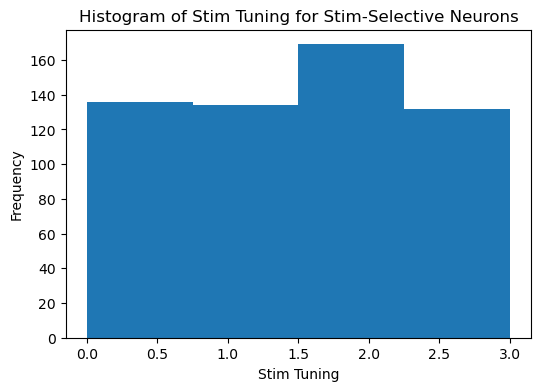

In [3]:
# get the neurons that are stim-selective during the stim period

model_name = model_names[0]
model_dir = os.path.join(all_models_dir, model_name)

stim1_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
stim_selective = np.where(~np.isnan(stim1_stimtuning))[0]
print(f"Number of stim-selective neurons: {len(stim_selective)}")

# plot histogram of stim tuning for the stim-selective neurons
plt.figure(figsize=(6,4))
stim_tuning = stim1_stimtuning[stim_selective]
plt.hist(stim_tuning, bins=4)
plt.xlabel('Stim Tuning')
plt.ylabel('Frequency')
plt.title('Histogram of Stim Tuning for Stim-Selective Neurons')
plt.show()

### generate custom stim set (balancing match/mismatch)

load 1: 
- 20 match
    - 10 with pref as stim1
    - 10 without pref a stim1
- 20 mismatch
    - 10 with pref as stim1
    - 10 without pref a stim1

load 3:
- 60 match
    - 30 with pref
        - 10 with pref as stim1
        - 10 with pref as stim2
        - 10 with pref as stim3
    - 30 without pref
- 60 mismatch
    - 30 with pref
        - 10 with pref as stim1
        - 10 with pref as stim2
        - 10 with pref as stim3
    - 30 without pref

In [5]:
def generate_input_stim_sternberg_pref_load1(settings, pref, incl_pref, match, max_load):
    # generate stimuli with or without the preferred stimulus
    # pref is the preferred stimulus (ie channel)
    # incl_pref is a boolean indicating whether to include the preferred channel in the stims
    # match is a boolean indicating whether to match the preferred channel for the probe
    
    t_total = int(settings["T"])
    stim_on = int(settings["stim_on"])
    stim_dur = int(settings["stim_dur"])
    delay = int(settings["delay"])
    load=1
    
    n_channels = 4
    stim_ids = np.full(max_load + 1, np.nan, dtype=np.float32)
    u = np.zeros((n_channels, t_total), dtype=np.float32)
    
    if incl_pref:
        stim_chan_idx = [pref]
    else:
        # choose a random channel that is not the preferred channel
        stim_chan_idx = np.random.choice(np.delete(np.arange(n_channels), pref), load, replace=False)
    stim_ids[:load] = stim_chan_idx
    
    ending_idx = stim_on
    for i, i_chan in enumerate(stim_chan_idx):
        if i == 0:
            u[i_chan, stim_on : stim_on + stim_dur] = 1.0
            ending_idx = stim_on + stim_dur
        else:
            u[i_chan, ending_idx : ending_idx + stim_dur] = 1.0
            ending_idx = ending_idx + stim_dur
    
    if match == 1:
        match_chan_idx = int(np.random.choice(stim_chan_idx, 1)[0])
        u[match_chan_idx, ending_idx + delay : ending_idx + delay + stim_dur] = 1.0
        stim_ids[max_load] = match_chan_idx
        label = 1
    elif match == 0:
        non_stim_chan_idx = np.setdiff1d(np.arange(n_channels), stim_chan_idx)
        non_match_chan_idx = int(np.random.choice(non_stim_chan_idx, 1)[0])
        u[non_match_chan_idx, ending_idx + delay : ending_idx + delay + stim_dur] = 1.0
        stim_ids[max_load] = non_match_chan_idx
        label = -1
    else:
        raise ValueError("match must be 0 or 1")

    return u, label, stim_ids

In [6]:
def generate_input_stim_sternberg_pref_load3(settings, pref, incl_pref, pref_pos, match, match_pref=None, max_load=3):
    # generate stimuli with or without the preferred stimulus
    # pref is the preferred stimulus (ie channel)
    # incl_pref is a boolean indicating whether to include the preferred channel in the stims
    # pref_pos is the index of the stimulus number to put the preferred channel
    # match is a boolean indicating whether to match the preferred channel for the probe
    
    t_total = int(settings["T"])
    stim_on = int(settings["stim_on"])
    stim_dur = int(settings["stim_dur"])
    delay = int(settings["delay"])
    load=3
    
    n_channels = 4
    stim_ids = np.full(max_load + 1, np.nan, dtype=np.float32)
    u = np.zeros((n_channels, t_total), dtype=np.float32)
    
    # choose channels to activate
    stim_chan_idx = np.random.choice(np.delete(np.arange(n_channels), pref), load, replace=False) # random channels that are not the preferred channel
    if incl_pref:
        # replace the specified stim position with the preferred channel
        stim_chan_idx[pref_pos] = pref
    stim_ids[:load] = stim_chan_idx
    
    ending_idx = stim_on
    for i, i_chan in enumerate(stim_chan_idx):
        if i == 0:
            u[i_chan, stim_on : stim_on + stim_dur] = 1.0
            ending_idx = stim_on + stim_dur
        else:
            u[i_chan, ending_idx : ending_idx + stim_dur] = 1.0
            ending_idx = ending_idx + stim_dur
    
    if match == 1:
        if (incl_pref==1) and (match_pref is not None): # for match trials with pref shown as a stim
            if match_pref: # probe should be the preferred stim
                match_chan_idx = pref
            else: # probe is not the preferred stim
                non_pref_stims = np.setdiff1d(stim_chan_idx, pref)
                match_chan_idx = int(np.random.choice(non_pref_stims, 1)[0])
        else:
            match_chan_idx = int(np.random.choice(stim_chan_idx, 1)[0])
        u[match_chan_idx, ending_idx + delay : ending_idx + delay + stim_dur] = 1.0
        stim_ids[max_load] = match_chan_idx
        label = 1
    elif match == 0:
        non_stim_chan_idx = np.setdiff1d(np.arange(n_channels), stim_chan_idx)
        non_match_chan_idx = int(np.random.choice(non_stim_chan_idx, 1)[0])
        u[non_match_chan_idx, ending_idx + delay : ending_idx + delay + stim_dur] = 1.0
        stim_ids[max_load] = non_match_chan_idx
        label = -1
    else:
        raise ValueError("match must be 0 or 1")

    return u, label, stim_ids

In [7]:
# function version without plotting

def generate_stimset(pref, settings):
    
    # generate load-1 first
    load = 1
    n_trials = 20
    u_all = []
    trial_type_all = []
    for match in [0, 1]:
        for incl_pref in [1, 0]:
            for i in range(n_trials):
                u, label, stim_ids = generate_input_stim_sternberg_pref_load1(settings, pref, incl_pref, match, 
                                                                        max_load=3)
                u_all.append(u)
                trial_type_all.append(np.concatenate((np.array([load, label], dtype=np.float32), stim_ids.flatten())))
                
    # now load-3
    match_pref=None
    load = 3
    n_trials = 10
    for match in [0, 1]:
        for incl_pref in [1, 0]:
            for pref_pos in [0, 1, 2]:
                for i in range(n_trials):
                    if match == 1 & incl_pref == 1:
                        # for half of trials, use the preferred channel for the match
                        if i < n_trials // 2:
                            match_pref = True
                        else:
                            match_pref = False
                        u, label, stim_ids = generate_input_stim_sternberg_pref_load3(settings, pref, incl_pref, pref_pos,
                                                                                    match, match_pref=match_pref, max_load=3)
                    else:
                        match_pref=None
                        u, label, stim_ids = generate_input_stim_sternberg_pref_load3(settings, pref, incl_pref, pref_pos,
                                                                                    match, max_load=3)
                    u_all.append(u)
                    trial_type_all.append(np.concatenate((np.array([load, label], dtype=np.float32), stim_ids.flatten())))
                    
    return np.array(u_all), np.array(trial_type_all)

### lesioning with the new generated trial method

- `stim_selective` are the indices of the neurons with stim preferences during maint
    - need to separate by the preferred stim, `pref`
- `stim_tuning = stim1_stimtuning[stim_selective]` -- the stim that the neurons are tuned to
- use `settings` that match the default in `generate_rate_data_multiload.py`
- need to run `u_all, trial_type_all = generate_stimset(pref, settings)` for each `pref`

- `model_name` and `model_dir` match this model

In [8]:
settings =  {
    "T": 450,
    "stim_on": 50,
    "stim_dur": 25,
    # "delay": 200,
    "delay": 150,
    "DeltaT": 1,
    "taus": 20,
    "fs": 200,
    "task": "sternberg",
    "load": 1,
}

In [9]:
unique_stims = np.unique(stim_tuning)
for stim in unique_stims: # 0, 1, 2, 3
    neuron_idxs = stim_selective[stim_tuning == stim] # neuron indices for this specific stimulus
    u_all, trial_type_all = generate_stimset(pref=int(stim), settings=settings)

    grdm.generate_data(
        model_dir="/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3",
        pattern="*N_1000*.mat",
        n_repetitions=3,          # used by balance_stims (unused)
        eval_amp_threshold=0.7,
        workers=1,
        backend="torch",
        device="cuda",
        overwrite=False,
        mode="precomputed",     # or "balance_match" / "balance_stims"
        n_trials=50,              # used by balance_match (unused)
        loads=[1, 3],             # used by balance_match (unused)
        lesion="custom",
        lesion_inds=[(None, neuron_idxs)], # (postsyn, presyn)
        lesion_scale=0.5,
        lesion_tag=f"stim_stimpref_{stim:g}",
        include_models=[model_name],
        u_all = u_all,
        trial_type_all = trial_type_all
    )

Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901


## analyze behavioral data

#### start with one stim

In [4]:
# load data and do some behavioral tests!
condn_phrase='delay'
condn_num=150

unique_stims = np.unique(stim_tuning)
# for stim_tuning in [0, 1, 2, 3]: # 0, 1, 2, 3

stim_tuning = 0

other_labels=f'precomputed_lesion_stim_stimpref_{stim_tuning}'

_, rates_data = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= other_labels,
                                            all_models_dir = all_models_dir, load_LFP=False)
trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels=other_labels,
                                                    all_models_dir=all_models_dir)
settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                    other_labels=other_labels,
                                    all_models_dir=all_models_dir)

print(trial_labels.shape, trial_perfs.shape, trial_outputs.shape)

(200, 6) (200,) (200, 450)


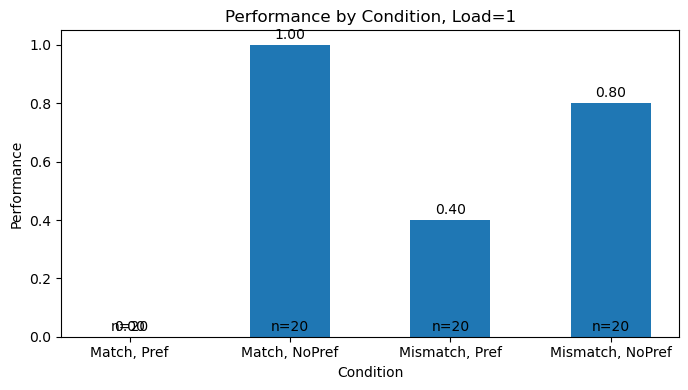

In [14]:
# first load 1, performance split by load, and whether preferred was shown or not

load1_idxs = np.where(trial_labels[:,0] == 1)[0]
match_idxs = np.where(trial_labels[:,1] == 1)[0]
mismatch_idxs = np.where(trial_labels[:,1] == -1)[0]
# pref_shown = np.where(np.any(trial_labels[:,2:5] == stim_tuning, axis=1))[0] # which trials had the preferred stimulus shown
pref_shown = np.where(trial_labels[:,2] == stim_tuning)[0]
pref_not_shown = np.where(trial_labels[:,2] != stim_tuning)[0]

load1_match_idxs = np.intersect1d(load1_idxs, match_idxs)
load1_mismatch_idxs = np.intersect1d(load1_idxs, mismatch_idxs)

match_pref = np.mean(trial_perfs[np.intersect1d(load1_match_idxs, pref_shown)])
match_nopref = np.mean(trial_perfs[np.intersect1d(load1_match_idxs, pref_not_shown)])
mismatch_pref = np.mean(trial_perfs[np.intersect1d(load1_mismatch_idxs, pref_shown)])
mismatch_nopref = np.mean(trial_perfs[np.intersect1d(load1_mismatch_idxs, pref_not_shown)])

# calculate n for each condition
n_match_pref = len(np.intersect1d(load1_match_idxs, pref_shown))
n_match_nopref = len(np.intersect1d(load1_match_idxs, pref_not_shown))
n_mismatch_pref = len(np.intersect1d(load1_mismatch_idxs, pref_shown))
n_mismatch_nopref = len(np.intersect1d(load1_mismatch_idxs, pref_not_shown))

plt.figure(figsize=(7,4))
plt.title('Performance by Condition, Load=1')
plt.bar([0, 1, 2, 3], [match_pref, match_nopref, mismatch_pref, mismatch_nopref], width=0.5)
plt.xticks([0, 1, 2, 3], ['Match, Pref', 'Match, NoPref', 'Mismatch, Pref', 'Mismatch, NoPref'])
# add percentage labels on top of each bar
for i, v in enumerate([match_pref, match_nopref, mismatch_pref, mismatch_nopref]):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom')
plt.xlabel('Condition')
plt.ylabel('Performance')
# add n labels on top of each bar
for i, n in enumerate([n_match_pref, n_match_nopref, n_mismatch_pref, n_mismatch_nopref]):
    plt.text(i, 0.01, f'n={n}', ha='center', va='bottom')
plt.tight_layout()
plt.show()


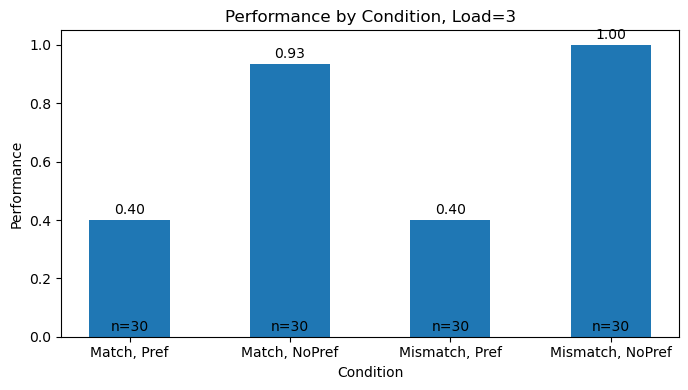

In [15]:
# now load=3 performance split by load, and whether preferred was shown or not

load3_idxs = np.where(trial_labels[:,0] == 3)[0]
match_idxs = np.where(trial_labels[:,1] == 1)[0]
mismatch_idxs = np.where(trial_labels[:,1] == -1)[0]
pref_shown = np.where(np.any(trial_labels[:,2:5] == stim_tuning, axis=1))[0] # which trials had the preferred stimulus shown
pref_not_shown = np.setdiff1d(np.arange(len(trial_labels)), pref_shown)

pref_1 = np.where(trial_labels[:,2] == stim_tuning)[0]
pref_2 = np.where(trial_labels[:,3] == stim_tuning)[0]
pref_3 = np.where(trial_labels[:,4] == stim_tuning)[0]
pref_probe = np.where(trial_labels[:,5] == stim_tuning)[0]

load3_match_idxs = np.intersect1d(load3_idxs, match_idxs)
load3_mismatch_idxs = np.intersect1d(load3_idxs, mismatch_idxs)

match_pref = np.mean(trial_perfs[np.intersect1d(load3_match_idxs, pref_shown)])
match_nopref = np.mean(trial_perfs[np.intersect1d(load3_match_idxs, pref_not_shown)])
mismatch_pref = np.mean(trial_perfs[np.intersect1d(load3_mismatch_idxs, pref_shown)])
mismatch_nopref = np.mean(trial_perfs[np.intersect1d(load3_mismatch_idxs, pref_not_shown)])

# calculate n for each condition
n_match_pref = len(np.intersect1d(load3_match_idxs, pref_shown))
n_match_nopref = len(np.intersect1d(load3_match_idxs, pref_not_shown))
n_mismatch_pref = len(np.intersect1d(load3_mismatch_idxs, pref_shown))
n_mismatch_nopref = len(np.intersect1d(load3_mismatch_idxs, pref_not_shown))

plt.figure(figsize=(7,4))
plt.title('Performance by Condition, Load=3')
plt.bar([0, 1, 2, 3], [match_pref, match_nopref, mismatch_pref, mismatch_nopref], width=0.5)
plt.xticks([0, 1, 2, 3], ['Match, Pref', 'Match, NoPref', 'Mismatch, Pref', 'Mismatch, NoPref'])
# add percentage labels on top of each bar
for i, v in enumerate([match_pref, match_nopref, mismatch_pref, mismatch_nopref]):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom')
plt.xlabel('Condition')
plt.ylabel('Performance')
# add n labels on top of each bar
for i, n in enumerate([n_match_pref, n_match_nopref, n_mismatch_pref, n_mismatch_nopref]):
    plt.text(i, 0.01, f'n={n}', ha='center', va='bottom')
    
plt.tight_layout()
plt.show()


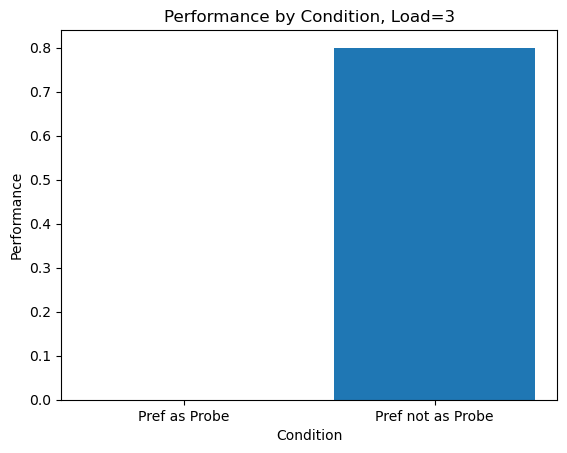

In [16]:
# for match, pref shown — difference between when pref was the probe or not?

pref_probe = np.where(trial_labels[:,5] == stim_tuning)[0]
pref_notprobe = np.where(trial_labels[:,5] != stim_tuning)[0]

match_pref = np.intersect1d(load3_match_idxs, pref_shown)
match_pref_probe = np.intersect1d(match_pref, pref_probe)
match_pref_notprobe = np.intersect1d(match_pref, pref_notprobe)

plt.bar([0, 1], [np.mean(trial_perfs[match_pref_probe]), np.mean(trial_perfs[match_pref_notprobe])])
plt.xlabel('Condition')
plt.ylabel('Performance')
plt.title('Performance by Condition, Load=3')
plt.xticks([0, 1], ['Pref as Probe', 'Pref not as Probe'])
plt.show()

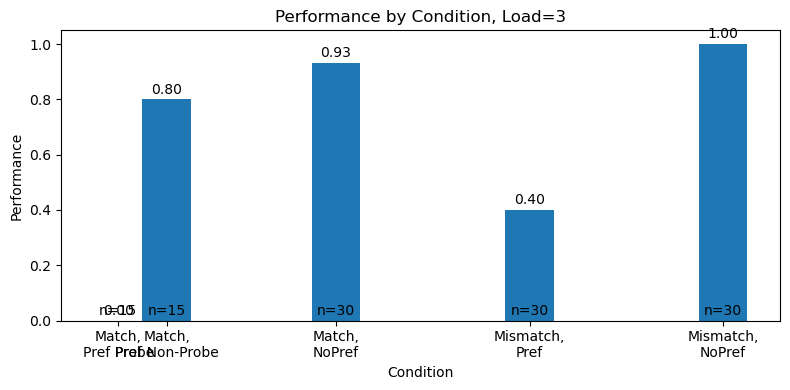

In [17]:
# Means
match_pref_probe_mean = np.mean(trial_perfs[match_pref_probe])
match_pref_notprobe_mean = np.mean(trial_perfs[match_pref_notprobe])

# Ns
n_match_pref_probe = len(match_pref_probe)
n_match_pref_notprobe = len(match_pref_notprobe)

# Bar positions
w = 0.25

x = [-w/2, w/2, 1, 2, 3]

heights = [
    match_pref_probe_mean,
    match_pref_notprobe_mean,
    match_nopref,
    mismatch_pref,
    mismatch_nopref
]

ns = [
    n_match_pref_probe,
    n_match_pref_notprobe,
    n_match_nopref,
    n_mismatch_pref,
    n_mismatch_nopref
]

plt.figure(figsize=(8,4))
plt.title('Performance by Condition, Load=3')

plt.bar(x, heights, width=w)

plt.xticks(
    x,
    [
        'Match,\nPref Probe',
        'Match,\nPref Non-Probe',
        'Match,\nNoPref',
        'Mismatch,\nPref',
        'Mismatch,\nNoPref'
    ]
)

# performance labels
for xpos, val in zip(x, heights):
    plt.text(
        xpos,
        val + 0.01,
        f'{val:.2f}',
        ha='center',
        va='bottom'
    )

# n labels
for xpos, n in zip(x, ns):
    plt.text(
        xpos,
        0.01,
        f'n={n}',
        ha='center',
        va='bottom'
    )

plt.xlabel('Condition')
plt.ylabel('Performance')
plt.tight_layout()
plt.show()

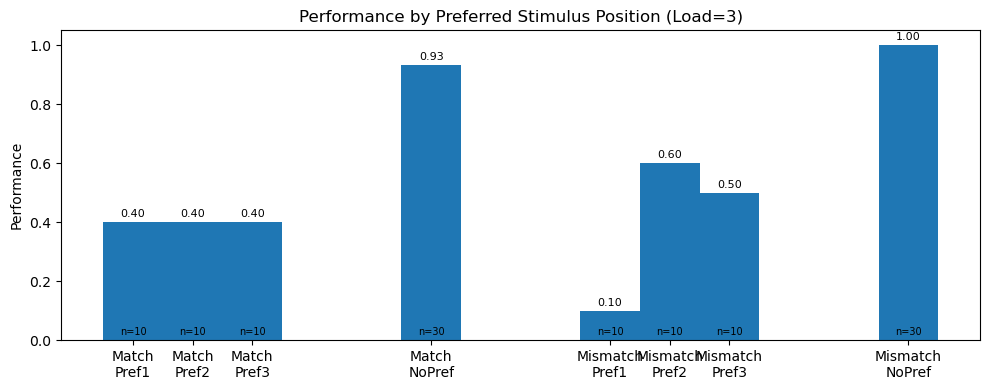

In [18]:
load3 = trial_labels[:,0] == 3
match = trial_labels[:,1] == 1
mismatch = trial_labels[:,1] == -1

prefs = {
    'Pref1': trial_labels[:,2] == stim_tuning,
    'Pref2': trial_labels[:,3] == stim_tuning,
    'Pref3': trial_labels[:,4] == stim_tuning,
}

prefs['NoPref'] = ~np.logical_or.reduce(list(prefs.values()))

conds = {
    f'Match\n{name}': load3 & match & mask
    for name, mask in prefs.items()
}

conds.update({
    f'Mismatch\n{name}': load3 & mismatch & mask
    for name, mask in prefs.items()
})

labels = list(conds.keys())
means = [trial_perfs[mask].mean() for mask in conds.values()]
ns = [mask.sum() for mask in conds.values()]

plt.figure(figsize=(10,4))
plt.title('Performance by Preferred Stimulus Position (Load=3)')

# x = np.arange(len(labels))
x = [-.25, 0, .25, 1, 1.75, 2, 2.25, 3]

plt.bar(x, means, width=0.25)

for xpos, val in zip(x, means):
    plt.text(
        xpos, val + 0.01,
        f'{val:.2f}',
        ha='center', va='bottom',
        fontsize=8
    )

for xpos, n in zip(x, ns):
    plt.text(
        xpos, 0.01,
        f'n={n}',
        ha='center', va='bottom',
        fontsize=7
    )

plt.xticks(x, labels)
plt.ylabel('Performance')
plt.title('Performance by Preferred Stimulus Position (Load=3)')
plt.tight_layout()
plt.show()

### compare to control, non-lesioned data

In [5]:
# load non-lesioned data
trial_labels_ctrl, trial_perfs_ctrl, _ = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num, other_labels='balance_stim', 
                                                               all_models_dir=all_models_dir)

print(trial_labels_ctrl.shape, trial_perfs_ctrl.shape)

(480, 6) (480,)


In [6]:
def get_stats(trial_labels, trial_perfs, stim_tuning, load):

    load_idxs = np.where(trial_labels[:,0] == load)[0]
    match_idxs = np.where(trial_labels[:,1] == 1)[0]
    mismatch_idxs = np.where(trial_labels[:,1] == -1)[0]

    # Define "pref shown" based on load
    if load == 1:
        pref_shown = np.where(trial_labels[:,2] == stim_tuning)[0]
    else:
        pref_shown = np.where(
            np.any(trial_labels[:,2:5] == stim_tuning, axis=1)
        )[0]

    pref_not_shown = np.setdiff1d(
        np.arange(len(trial_labels)),
        pref_shown
    )

    load_match_idxs = np.intersect1d(load_idxs, match_idxs)
    load_mismatch_idxs = np.intersect1d(load_idxs, mismatch_idxs)

    vals = [
        np.mean(trial_perfs[np.intersect1d(load_match_idxs, pref_shown)]),
        np.mean(trial_perfs[np.intersect1d(load_match_idxs, pref_not_shown)]),
        np.mean(trial_perfs[np.intersect1d(load_mismatch_idxs, pref_shown)]),
        np.mean(trial_perfs[np.intersect1d(load_mismatch_idxs, pref_not_shown)])
    ]

    ns = [
        len(np.intersect1d(load_match_idxs, pref_shown)),
        len(np.intersect1d(load_match_idxs, pref_not_shown)),
        len(np.intersect1d(load_mismatch_idxs, pref_shown)),
        len(np.intersect1d(load_mismatch_idxs, pref_not_shown))
    ]

    return vals, ns

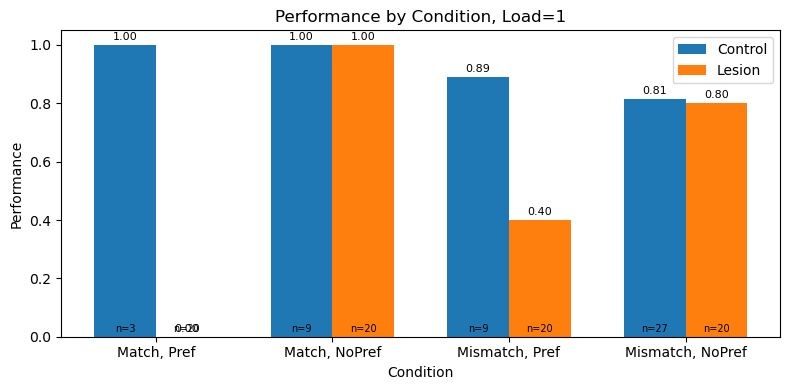

In [21]:
# compute stats
ctrl_vals, ctrl_ns = get_stats(trial_labels_ctrl, trial_perfs_ctrl, stim_tuning, load=1)
lesion_vals, lesion_ns = get_stats(trial_labels, trial_perfs, stim_tuning, load=1)

# grouped bar plot
x = np.arange(4)
width = 0.35

plt.figure(figsize=(8,4))
plt.title('Performance by Condition, Load=1')

plt.bar(x - width/2, ctrl_vals, width=width, color='tab:blue', label='Control')
plt.bar(x + width/2, lesion_vals, width=width, color='tab:orange', label='Lesion')

plt.xticks(
    x,
    ['Match, Pref',
     'Match, NoPref',
     'Mismatch, Pref',
     'Mismatch, NoPref']
)

# performance labels
for xpos, val in zip(x - width/2, ctrl_vals):
    plt.text(xpos, val + 0.01, f'{val:.2f}',
             ha='center', va='bottom', fontsize=8)

for xpos, val in zip(x + width/2, lesion_vals):
    plt.text(xpos, val + 0.01, f'{val:.2f}',
             ha='center', va='bottom', fontsize=8)

# n labels near bottom
for xpos, n in zip(x - width/2, ctrl_ns):
    plt.text(xpos, 0.01, f'n={n}',
             ha='center', va='bottom', fontsize=7, color='k')

for xpos, n in zip(x + width/2, lesion_ns):
    plt.text(xpos, 0.01, f'n={n}',
             ha='center', va='bottom', fontsize=7, color='k')

plt.xlabel('Condition')
plt.ylabel('Performance')
plt.legend()
plt.tight_layout()
plt.show()

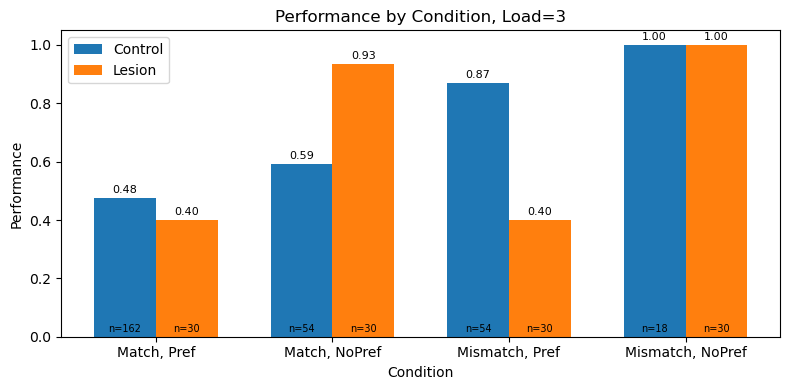

In [22]:
# Compute stats
ctrl_vals, ctrl_ns = get_stats(trial_labels_ctrl, trial_perfs_ctrl, stim_tuning, load=3)
lesion_vals, lesion_ns = get_stats(trial_labels, trial_perfs, stim_tuning, load=3)

# Plot
x = np.arange(4)
width = 0.35

plt.figure(figsize=(8,4))
plt.title('Performance by Condition, Load=3')

plt.bar(x - width/2, ctrl_vals, width=width, color='tab:blue', label='Control')
plt.bar(x + width/2, lesion_vals, width=width, color='tab:orange', label='Lesion')

plt.xticks(
    x,
    [
        'Match, Pref',
        'Match, NoPref',
        'Mismatch, Pref',
        'Mismatch, NoPref'
    ]
)

# value labels
for xpos, val in zip(x - width/2, ctrl_vals):
    plt.text(
        xpos, val + 0.01,
        f'{val:.2f}',
        ha='center', va='bottom',
        fontsize=8
    )

for xpos, val in zip(x + width/2, lesion_vals):
    plt.text(
        xpos, val + 0.01,
        f'{val:.2f}',
        ha='center', va='bottom',
        fontsize=8
    )

# n labels
for xpos, n in zip(x - width/2, ctrl_ns):
    plt.text(
        xpos, 0.01,
        f'n={n}',
        ha='center', va='bottom',
        fontsize=7,
        color='k'
    )

for xpos, n in zip(x + width/2, lesion_ns):
    plt.text(
        xpos, 0.01,
        f'n={n}',
        ha='center', va='bottom',
        fontsize=7,
        color='k'
    )

plt.xlabel('Condition')
plt.ylabel('Performance')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
def get_pref_probe_stats(trial_labels, trial_perfs, stim_tuning):

    load3_idxs = np.where(trial_labels[:,0] == 3)[0]
    match_idxs = np.where(trial_labels[:,1] == 1)[0]

    pref_shown = np.where(
        np.any(trial_labels[:,2:5] == stim_tuning, axis=1)
    )[0]

    pref_probe = np.where(trial_labels[:,5] == stim_tuning)[0]
    pref_notprobe = np.where(trial_labels[:,5] != stim_tuning)[0]

    match_pref = np.intersect1d(
        np.intersect1d(load3_idxs, match_idxs),
        pref_shown
    )

    match_pref_probe = np.intersect1d(match_pref, pref_probe)
    match_pref_notprobe = np.intersect1d(match_pref, pref_notprobe)

    vals = [
        np.mean(trial_perfs[match_pref_probe]),
        np.mean(trial_perfs[match_pref_notprobe])
    ]

    ns = [
        len(match_pref_probe),
        len(match_pref_notprobe)
    ]

    return vals, ns

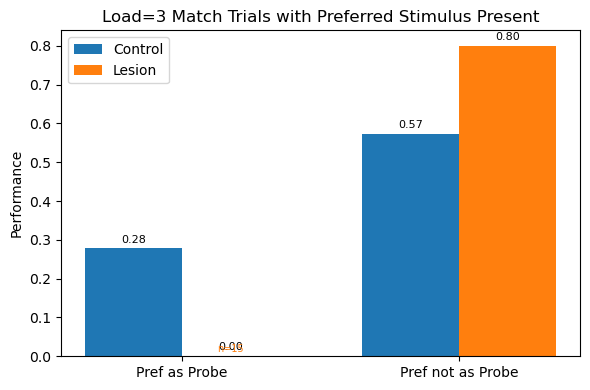

In [24]:
ctrl_vals, ctrl_ns = get_pref_probe_stats(
    trial_labels_ctrl,
    trial_perfs_ctrl,
    stim_tuning
)

lesion_vals, lesion_ns = get_pref_probe_stats(
    trial_labels,
    trial_perfs,
    stim_tuning
)

x = np.arange(2)
width = 0.35

plt.figure(figsize=(6,4))

plt.bar(
    x - width/2,
    ctrl_vals,
    width=width,
    color='tab:blue',
    label='Control'
)

plt.bar(
    x + width/2,
    lesion_vals,
    width=width,
    color='tab:orange',
    label='Lesion'
)

plt.xticks(
    x,
    ['Pref as Probe', 'Pref not as Probe']
)

# value labels
for xpos, val in zip(x - width/2, ctrl_vals):
    plt.text(xpos, val + 0.01, f'{val:.2f}',
             ha='center', va='bottom', fontsize=8)

for xpos, val in zip(x + width/2, lesion_vals):
    plt.text(xpos, val + 0.01, f'{val:.2f}',
             ha='center', va='bottom', fontsize=8)

# n labels
for xpos, n in zip(x - width/2, ctrl_ns):
    plt.text(xpos, 0.01, f'n={n}',
             ha='center', color='tab:blue', fontsize=7)

for xpos, n in zip(x + width/2, lesion_ns):
    plt.text(xpos, 0.01, f'n={n}',
             ha='center', color='tab:orange', fontsize=7)

plt.ylabel('Performance')
plt.title('Load=3 Match Trials with Preferred Stimulus Present')
plt.legend()
plt.tight_layout()
plt.show()

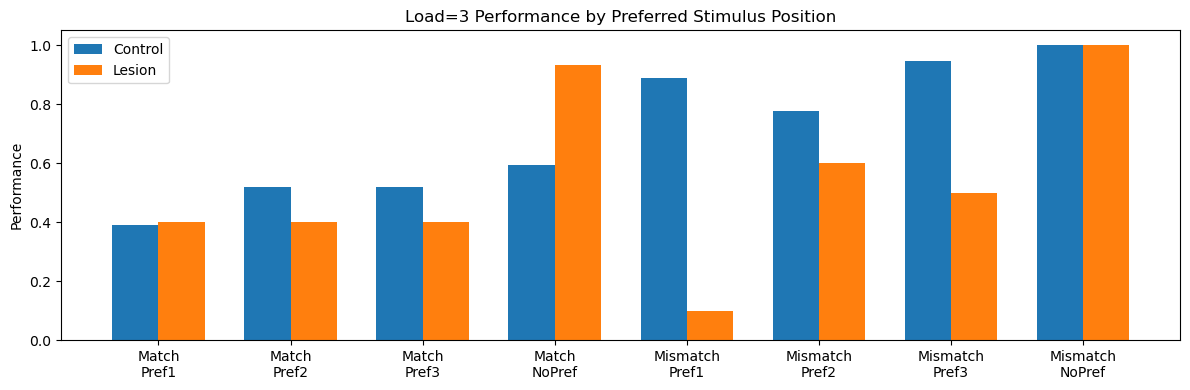

In [8]:
def get_means_ns(trial_labels, trial_perfs, stim_tuning):

    load3 = trial_labels[:,0] == 3
    match = trial_labels[:,1] == 1
    mismatch = trial_labels[:,1] == -1

    prefs = {
        'Pref1': trial_labels[:,2] == stim_tuning,
        'Pref2': trial_labels[:,3] == stim_tuning,
        'Pref3': trial_labels[:,4] == stim_tuning,
    }

    prefs['NoPref'] = ~np.logical_or.reduce(list(prefs.values()))

    conds = {
        f'Match\n{name}': load3 & match & mask
        for name, mask in prefs.items()
    }

    conds.update({
        f'Mismatch\n{name}': load3 & mismatch & mask
        for name, mask in prefs.items()
    })

    means = [trial_perfs[m].mean() for m in conds.values()]
    ns = [m.sum() for m in conds.values()]

    return list(conds.keys()), means, ns

labels, ctrl_means, ctrl_ns = get_means_ns(
    trial_labels_ctrl,
    trial_perfs_ctrl,
    stim_tuning
)

_, lesion_means, lesion_ns = get_means_ns(
    trial_labels,
    trial_perfs,
    stim_tuning
)

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12,4))

plt.bar(x - width/2, ctrl_means, width,
        color='tab:blue', label='Control')
plt.bar(x + width/2, lesion_means, width,
        color='tab:orange', label='Lesion')

plt.xticks(x, labels)
plt.ylabel('Performance')
plt.title('Load=3 Performance by Preferred Stimulus Position')
plt.legend()

plt.tight_layout()
plt.show()

### put it all into one figure

In [10]:
def plot_grouped_bars(ax, ctrl_vals, lesion_vals,
                      ctrl_ns, lesion_ns,
                      labels, title,
                      ylabel='Performance',
                      show_legend=False):

    x = np.arange(len(labels))
    width = 0.35

    ax.bar(x - width/2, ctrl_vals, width,
           color='tab:blue', label='Control')
    ax.bar(x + width/2, lesion_vals, width,
           color='tab:orange', label='Lesion')

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.1)

    for xpos, val in zip(x - width/2, ctrl_vals):
        ax.text(xpos, val + 0.01, f'{val:.2f}',
                ha='center', va='bottom', fontsize=10)

    for xpos, val in zip(x + width/2, lesion_vals):
        ax.text(xpos, val + 0.01, f'{val:.2f}',
                ha='center', va='bottom', fontsize=10)

    for xpos, n in zip(x - width/2, ctrl_ns):
        ax.text(xpos, 0.01, f'n={n}',
                ha='center', fontsize=10)

    for xpos, n in zip(x + width/2, lesion_ns):
        ax.text(xpos, 0.01, f'n={n}',
                ha='center', fontsize=10)

    if show_legend:
        ax.legend()

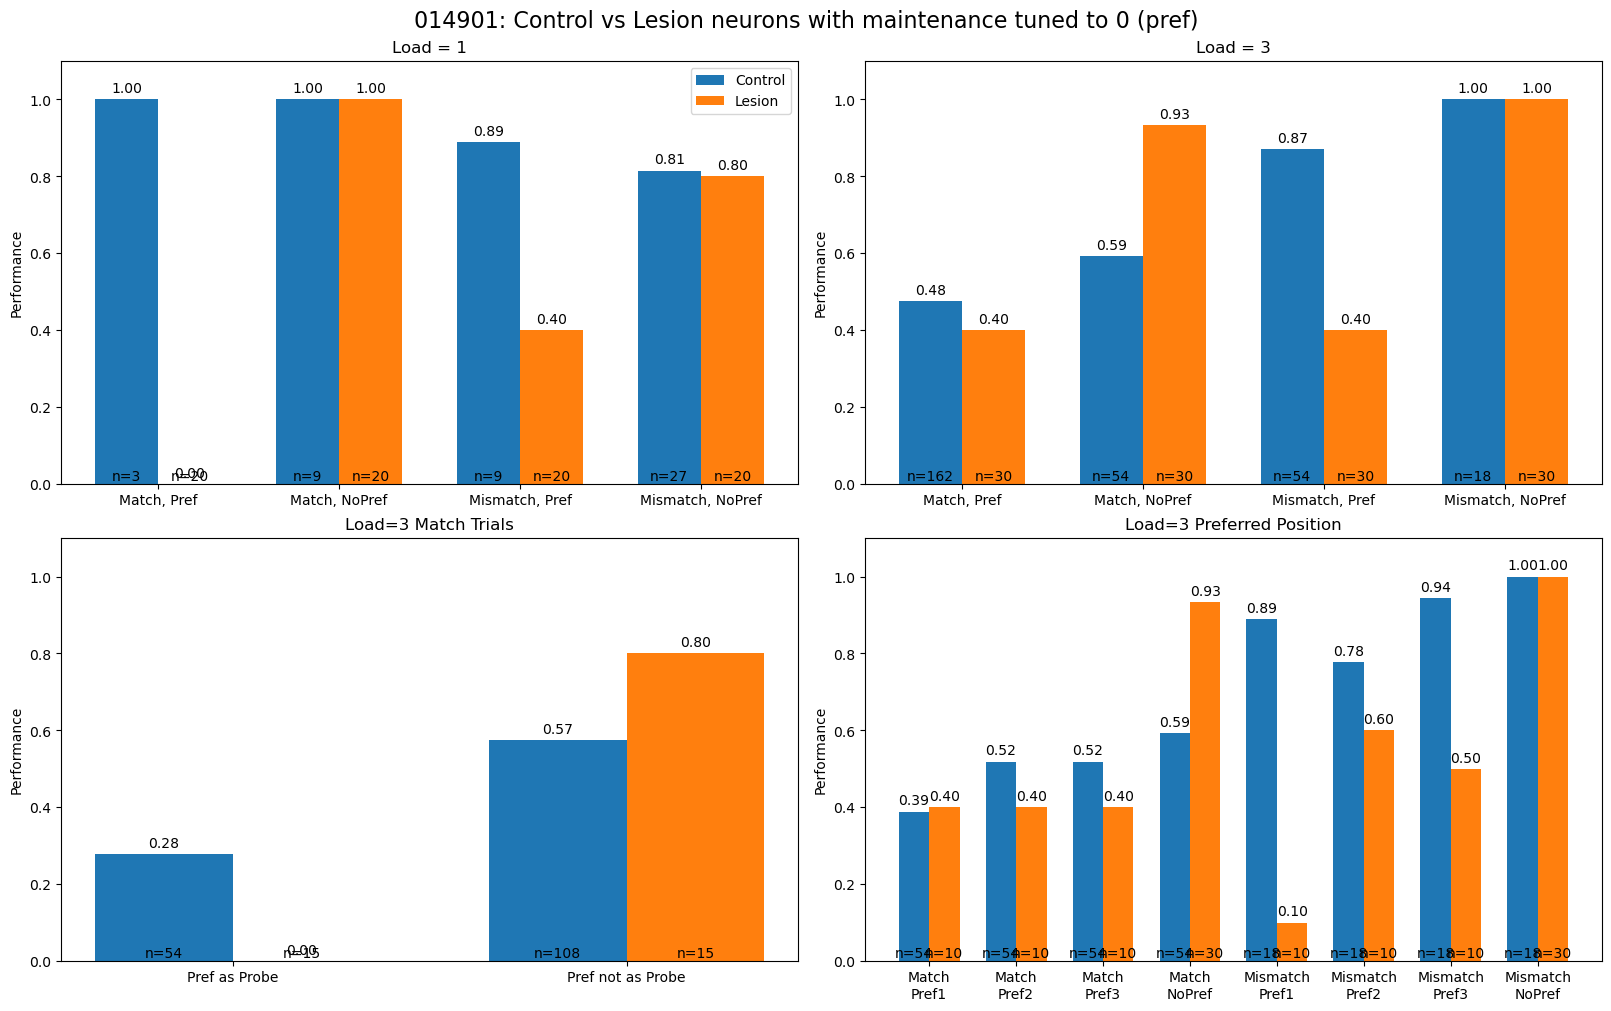

In [11]:
fig, axs = plt.subplots(
    2, 2,
    figsize=(16, 10),
    constrained_layout=True
)

# panel 1: load=1
ctrl_vals, ctrl_ns = get_stats(
    trial_labels_ctrl, trial_perfs_ctrl,
    stim_tuning, load=1
)

lesion_vals, lesion_ns = get_stats(
    trial_labels, trial_perfs,
    stim_tuning, load=1
)

plot_grouped_bars(
    axs[0,0],
    ctrl_vals, lesion_vals,
    ctrl_ns, lesion_ns,
    ['Match, Pref',
     'Match, NoPref',
     'Mismatch, Pref',
     'Mismatch, NoPref'],
    'Load = 1',
    show_legend=True
)

# panel 2: load=3
ctrl_vals, ctrl_ns = get_stats(
    trial_labels_ctrl, trial_perfs_ctrl,
    stim_tuning, load=3
)

lesion_vals, lesion_ns = get_stats(
    trial_labels, trial_perfs,
    stim_tuning, load=3
)

plot_grouped_bars(
    axs[0,1],
    ctrl_vals, lesion_vals,
    ctrl_ns, lesion_ns,
    ['Match, Pref',
     'Match, NoPref',
     'Mismatch, Pref',
     'Mismatch, NoPref'],
    'Load = 3'
)

# panel 3: load=3, for match probe in, is pref the probe
ctrl_vals, ctrl_ns = get_pref_probe_stats(
    trial_labels_ctrl,
    trial_perfs_ctrl,
    stim_tuning
)

lesion_vals, lesion_ns = get_pref_probe_stats(
    trial_labels,
    trial_perfs,
    stim_tuning
)

plot_grouped_bars(
    axs[1,0],
    ctrl_vals, lesion_vals,
    ctrl_ns, lesion_ns,
    ['Pref as Probe',
     'Pref not as Probe'],
    'Load=3 Match Trials'
)

# panel 4: load=3, preferred in specific position
labels, ctrl_vals, ctrl_ns = get_means_ns(
    trial_labels_ctrl,
    trial_perfs_ctrl,
    stim_tuning
)

_, lesion_vals, lesion_ns = get_means_ns(
    trial_labels,
    trial_perfs,
    stim_tuning
)

plot_grouped_bars(
    axs[1,1],
    ctrl_vals, lesion_vals,
    ctrl_ns, lesion_ns,
    labels,
    'Load=3 Preferred Position'
)

# add a title to the figure
fig.suptitle(
    f'{model_name[-6:]}: Control vs Lesion neurons with maintenance tuned to {stim_tuning} (pref)',
    fontsize=16
)

plt.show()

### now all stims

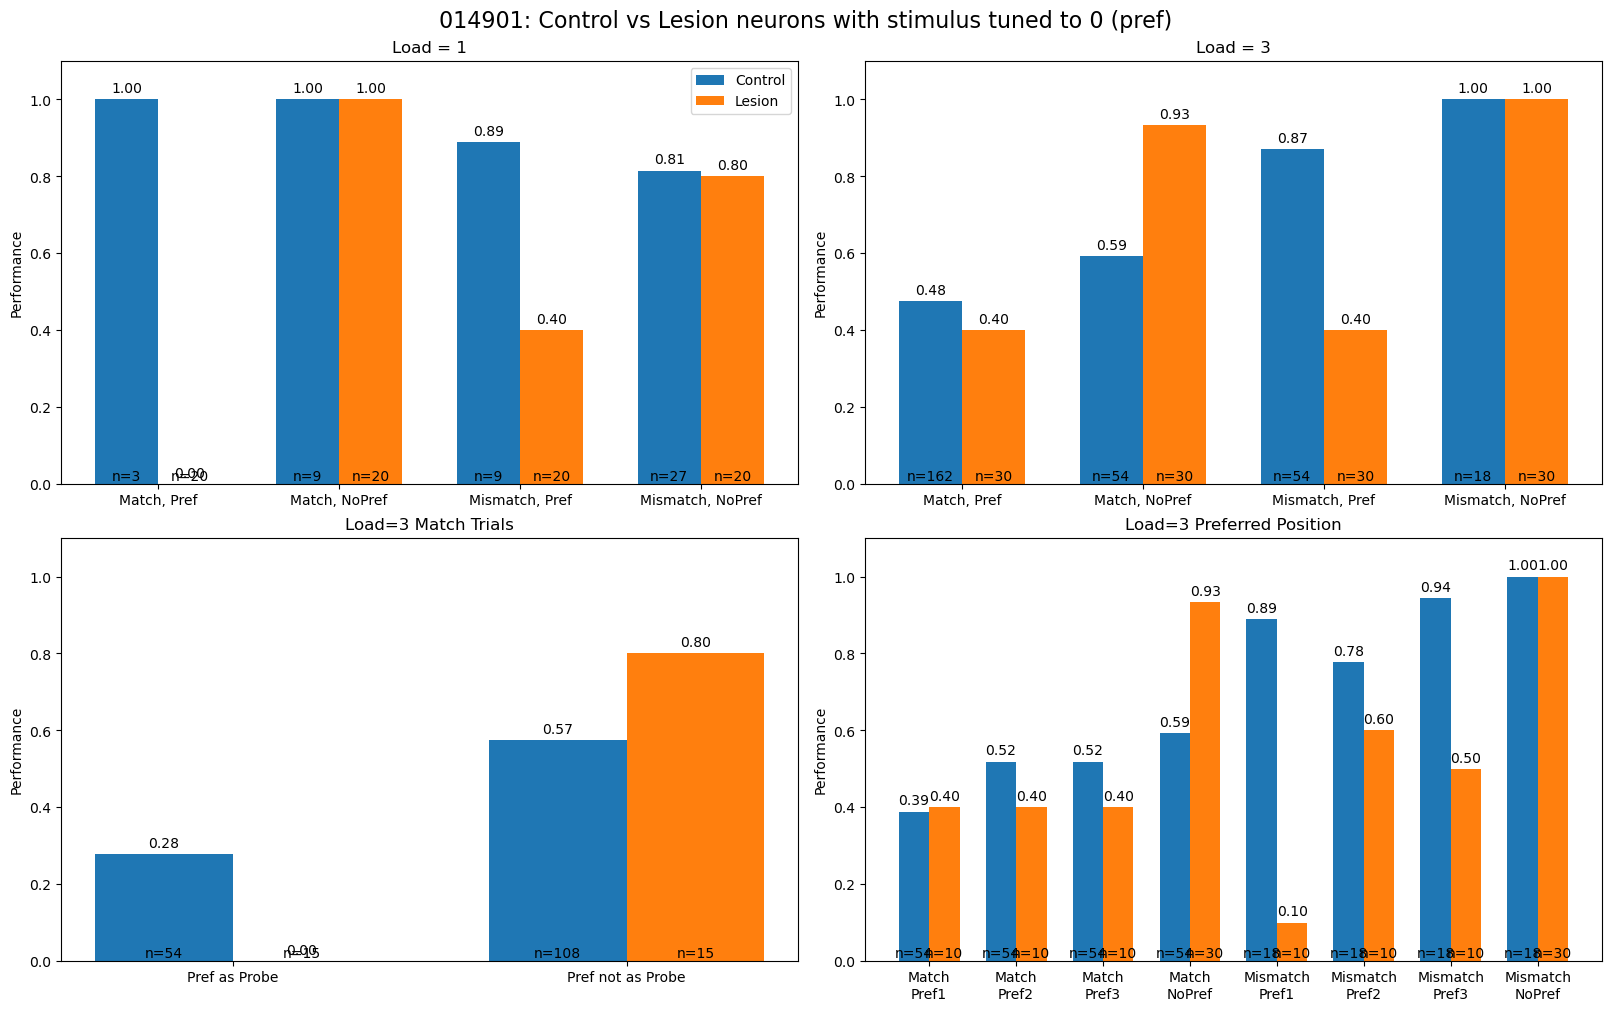

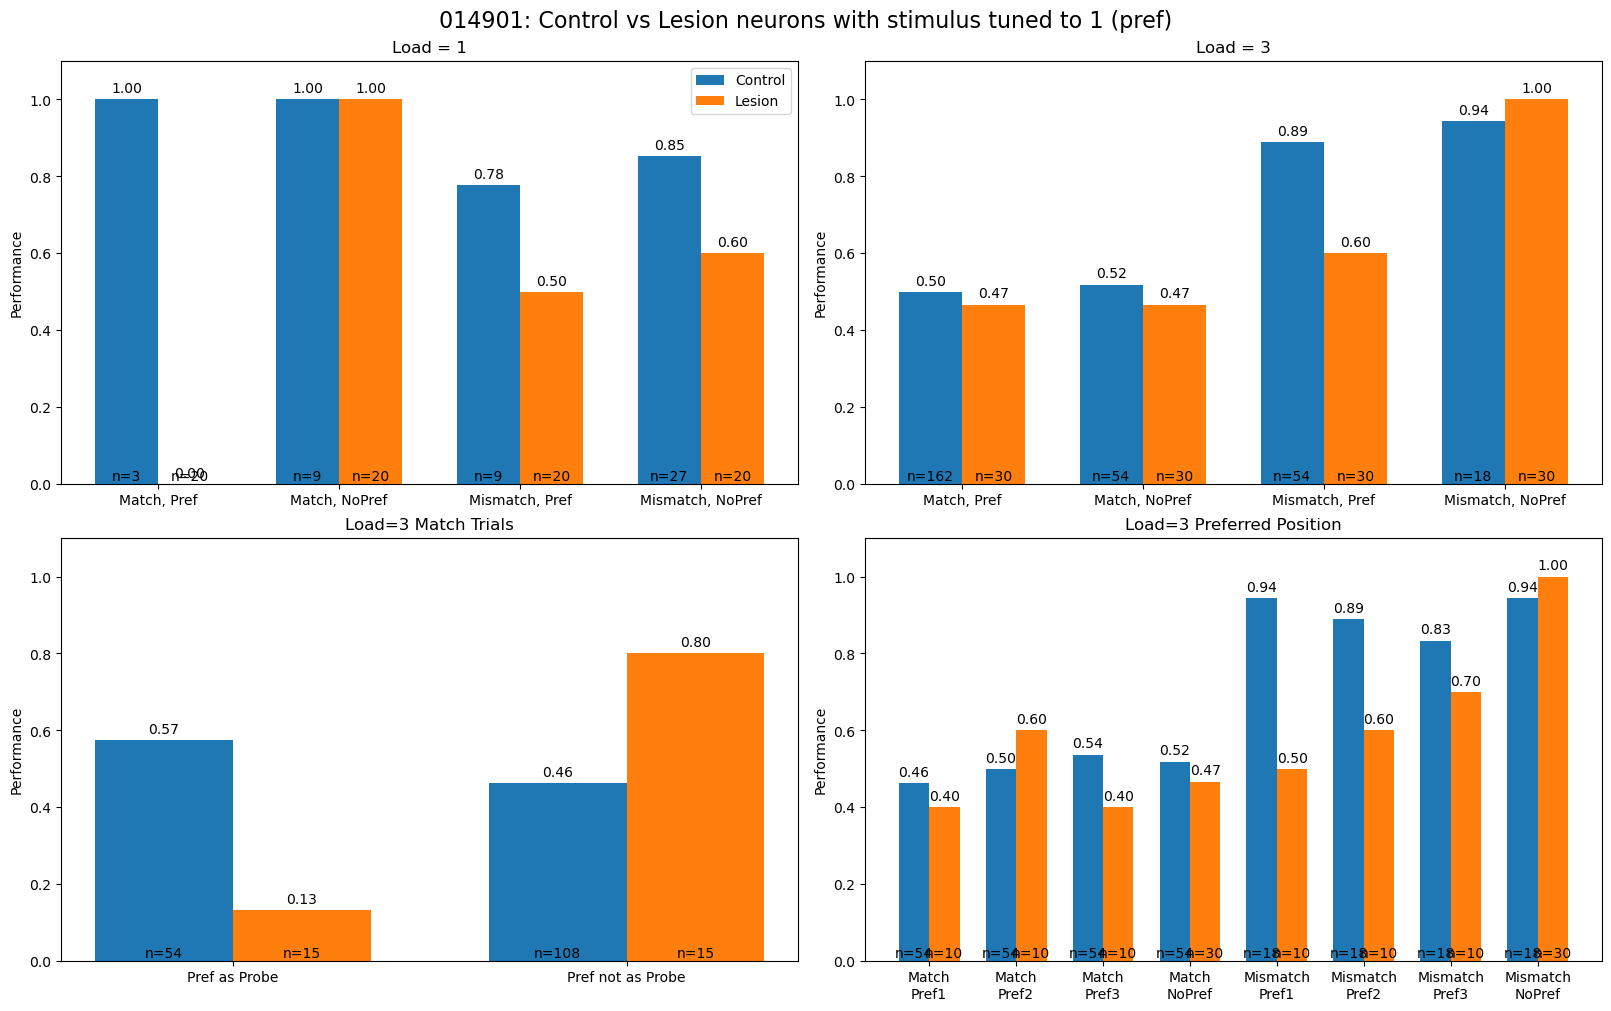

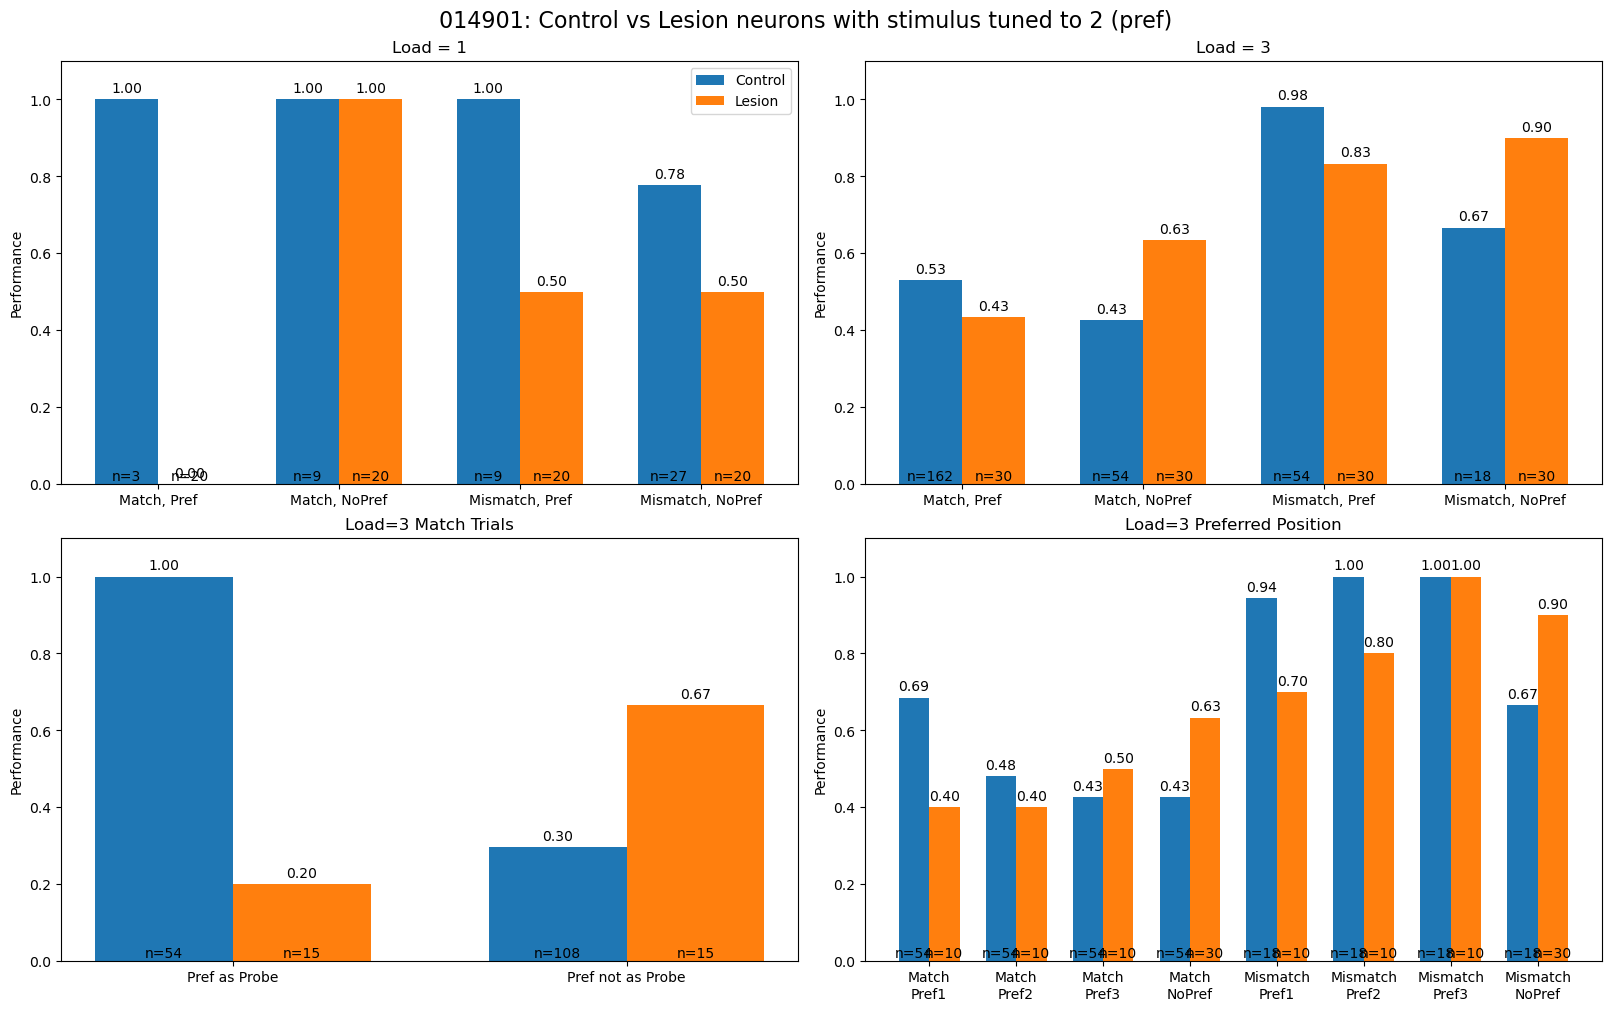

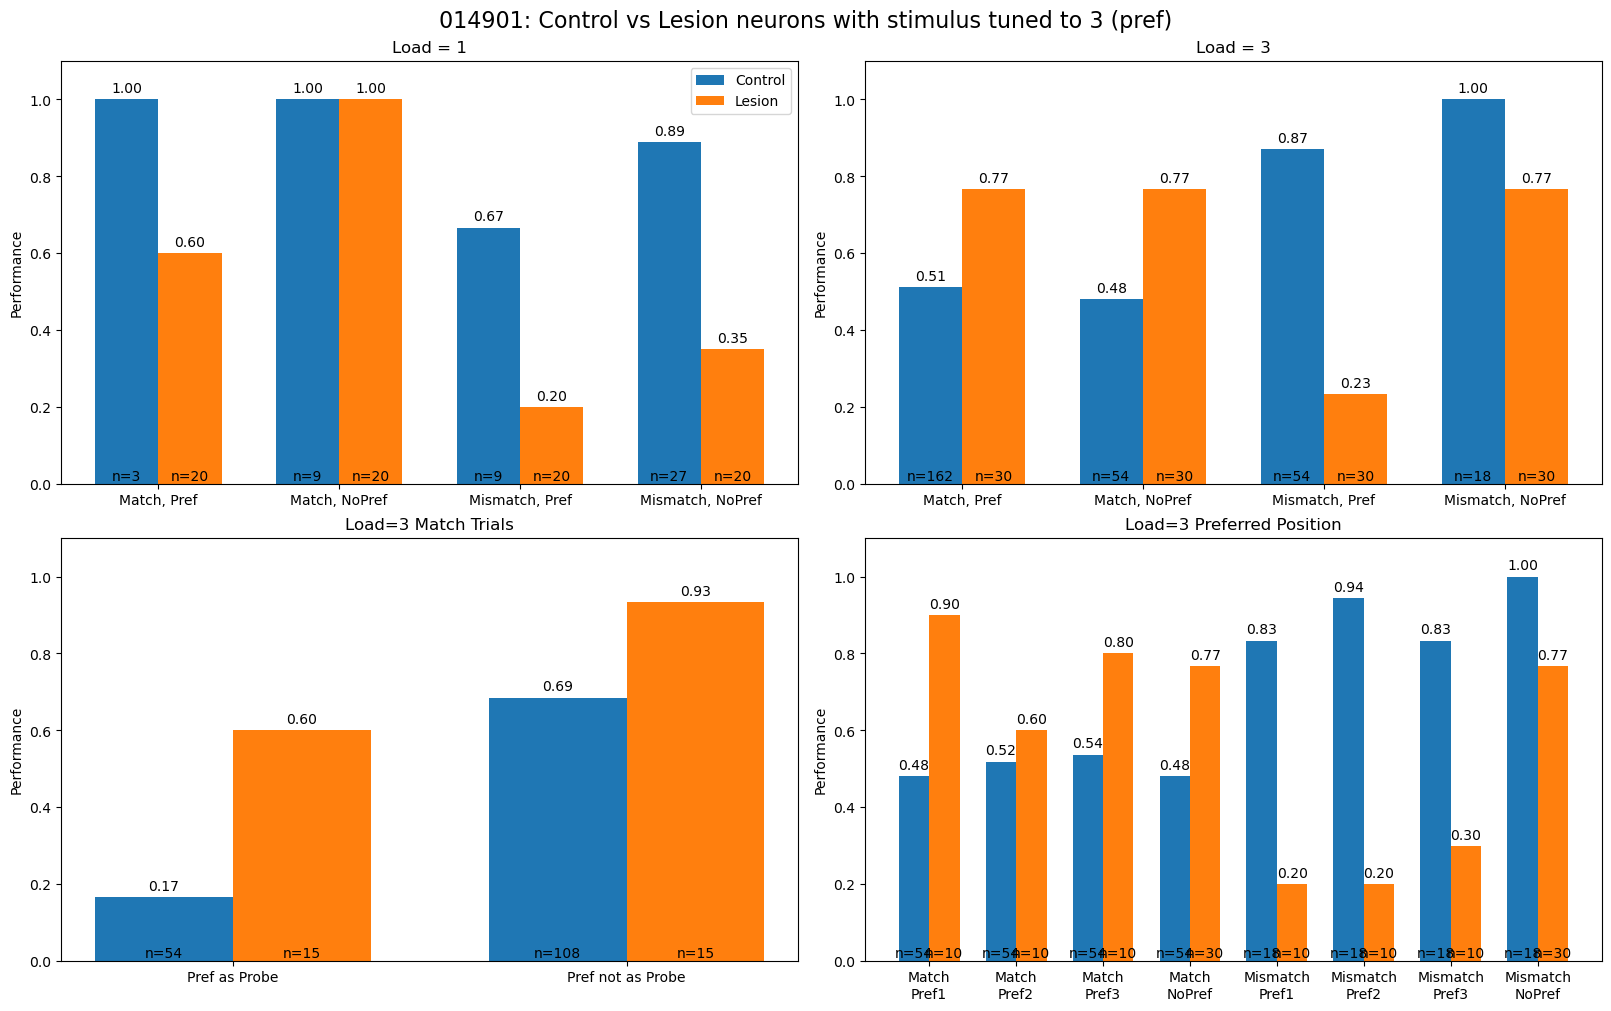

In [12]:
# load data and do some behavioral tests!
condn_phrase='delay'
condn_num=150

# load non-lesioned data
trial_labels_ctrl, trial_perfs_ctrl, _ = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num, other_labels='balance_stim', 
                                                            all_models_dir=all_models_dir)

unique_stims = np.unique(stim_tuning)
for stim_tuning in [0, 1, 2, 3]: # 0, 1, 2, 3

    other_labels=f'precomputed_lesion_stim_stimpref_{stim_tuning}'

    trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels=other_labels,
                                                        all_models_dir=all_models_dir)
    
    
    fig, axs = plt.subplots(
        2, 2,
        figsize=(16, 10),
        constrained_layout=True
    )

    # panel 1: load=1
    ctrl_vals, ctrl_ns = get_stats(
        trial_labels_ctrl, trial_perfs_ctrl,
        stim_tuning, load=1
    )

    lesion_vals, lesion_ns = get_stats(
        trial_labels, trial_perfs,
        stim_tuning, load=1
    )

    plot_grouped_bars(
        axs[0,0],
        ctrl_vals, lesion_vals,
        ctrl_ns, lesion_ns,
        ['Match, Pref',
        'Match, NoPref',
        'Mismatch, Pref',
        'Mismatch, NoPref'],
        'Load = 1',
        show_legend=True
    )

    # panel 2: load=3
    ctrl_vals, ctrl_ns = get_stats(
        trial_labels_ctrl, trial_perfs_ctrl,
        stim_tuning, load=3
    )

    lesion_vals, lesion_ns = get_stats(
        trial_labels, trial_perfs,
        stim_tuning, load=3
    )

    plot_grouped_bars(
        axs[0,1],
        ctrl_vals, lesion_vals,
        ctrl_ns, lesion_ns,
        ['Match, Pref',
        'Match, NoPref',
        'Mismatch, Pref',
        'Mismatch, NoPref'],
        'Load = 3'
    )

    # panel 3: load=3, for match probe in, is pref the probe
    ctrl_vals, ctrl_ns = get_pref_probe_stats(
        trial_labels_ctrl,
        trial_perfs_ctrl,
        stim_tuning
    )

    lesion_vals, lesion_ns = get_pref_probe_stats(
        trial_labels,
        trial_perfs,
        stim_tuning
    )

    plot_grouped_bars(
        axs[1,0],
        ctrl_vals, lesion_vals,
        ctrl_ns, lesion_ns,
        ['Pref as Probe',
        'Pref not as Probe'],
        'Load=3 Match Trials'
    )

    # panel 4: load=3, preferred in specific position
    labels, ctrl_vals, ctrl_ns = get_means_ns(
        trial_labels_ctrl,
        trial_perfs_ctrl,
        stim_tuning
    )

    _, lesion_vals, lesion_ns = get_means_ns(
        trial_labels,
        trial_perfs,
        stim_tuning
    )

    plot_grouped_bars(
        axs[1,1],
        ctrl_vals, lesion_vals,
        ctrl_ns, lesion_ns,
        labels,
        'Load=3 Preferred Position'
    )

    # add a title to the figure
    fig.suptitle(
        f'{model_name[-6:]}: Control vs Lesion neurons with stimulus tuned to {stim_tuning} (pref)',
        fontsize=16
    )

    plt.show()

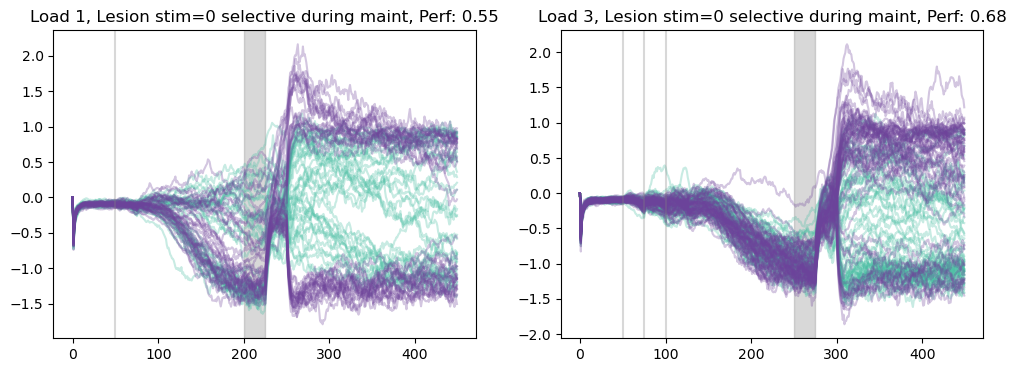

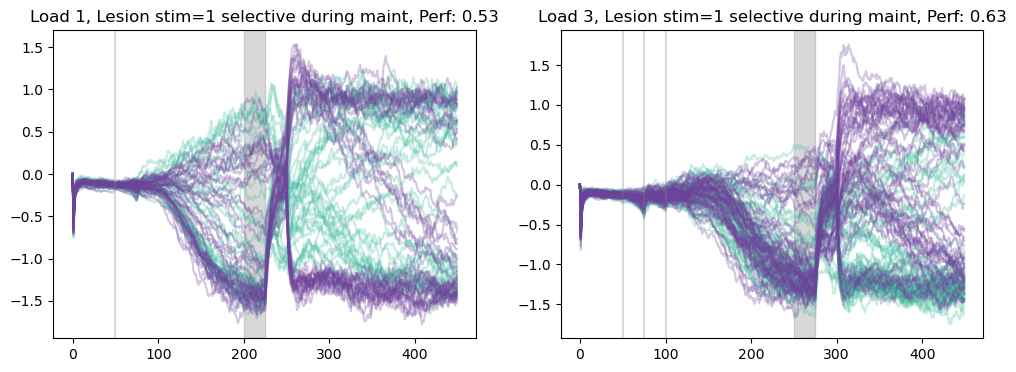

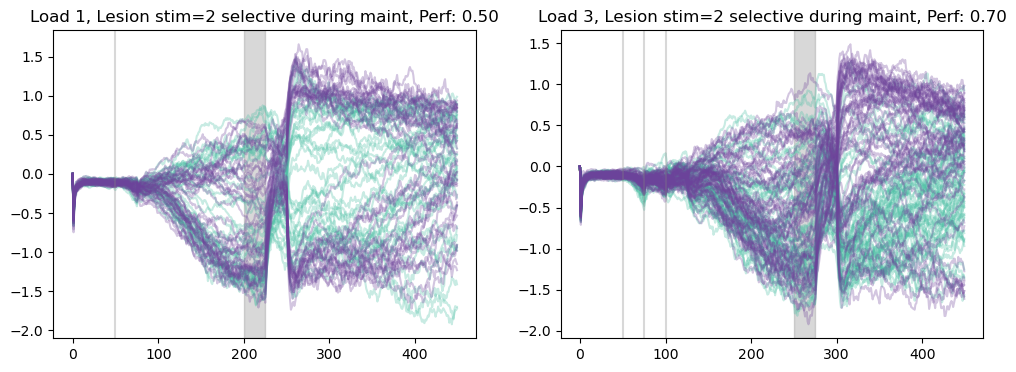

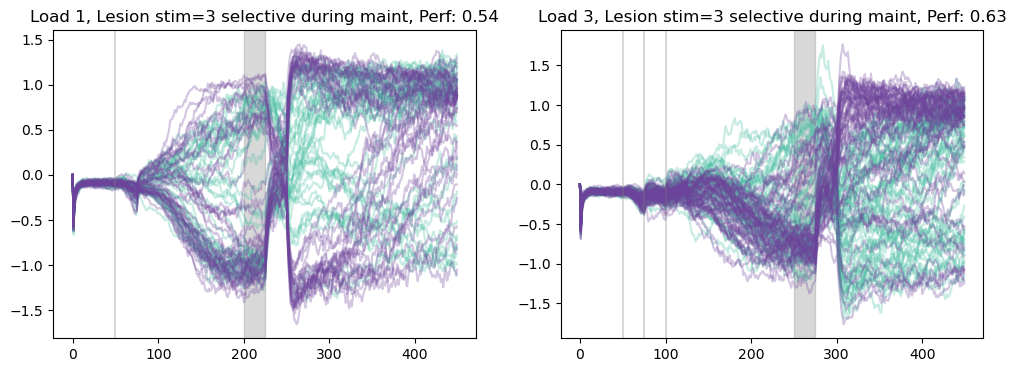

In [30]:
# check out the outputs to make sure it's ok
condn_phrase='delay'
condn_num=150

# load non-lesioned data
trial_labels_ctrl, trial_perfs_ctrl, _ = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num, other_labels='balance_stim', 
                                                            all_models_dir=all_models_dir)

unique_stims = np.unique(stim_tuning)
for stim_tuning in [0, 1, 2, 3]: # 0, 1, 2, 3

    other_labels=f'precomputed_lesion_stim_stimpref_{stim_tuning}'

    trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels=other_labels,
                                                        all_models_dir=all_models_dir)
    
    # plot outputs
    colors = ["#49BEA3", "#6E439A"]
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    for i, load in enumerate([1, 3]):
        this_load_idx = np.where(trial_labels[:, 0] == load)[0]
        for n in this_load_idx:
            axs[i].plot(
                trial_outputs[n],
                color=colors[int(trial_labels[n,1] == 1)],
                alpha=0.3,
            )

        perf = np.mean(np.array(trial_perfs)[this_load_idx])
        axs[i].set_title(f"Load {load}, Lesion stim={stim_tuning} selective during maint, Perf: {perf:.2f}")
        for n in range(load):
            stim_on = settings["stim_on"] + n * settings["stim_dur"]
            axs[i].axvline(stim_on, color="gray", alpha=0.3)
        axs[i].axvspan(
            stim_on + settings["delay"],
            stim_on + settings["delay"] + settings["stim_dur"],
            color="gray",
            alpha=0.3,
        )
    plt.show()

# Lesion by 100%

### start with one model

In [2]:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3'

model_paths = ['Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_041152.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_180002.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_233744.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_023239.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_043128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063647.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_153131.mat']

model_names = [os.path.basename(m)[:-4] for m in model_paths]

Number of stim-selective neurons: 571


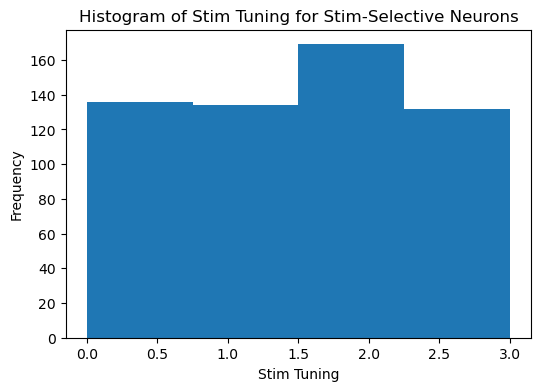

In [3]:
# get the neurons that are stim-selective during the stim period

model_name = model_names[0]
model_dir = os.path.join(all_models_dir, model_name)

stim1_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
stim_selective = np.where(~np.isnan(stim1_stimtuning))[0]
print(f"Number of stim-selective neurons: {len(stim_selective)}")

# plot histogram of stim tuning for the stim-selective neurons
plt.figure(figsize=(6,4))
stim_tuning = stim1_stimtuning[stim_selective]
plt.hist(stim_tuning, bins=4)
plt.xlabel('Stim Tuning')
plt.ylabel('Frequency')
plt.title('Histogram of Stim Tuning for Stim-Selective Neurons')
plt.show()

### generate custom stim set (balancing match/mismatch)

load 1: 
- 20 match
    - 10 with pref as stim1
    - 10 without pref a stim1
- 20 mismatch
    - 10 with pref as stim1
    - 10 without pref a stim1

load 3:
- 60 match
    - 30 with pref
        - 10 with pref as stim1
        - 10 with pref as stim2
        - 10 with pref as stim3
    - 30 without pref
- 60 mismatch
    - 30 with pref
        - 10 with pref as stim1
        - 10 with pref as stim2
        - 10 with pref as stim3
    - 30 without pref

In [4]:
def generate_input_stim_sternberg_pref_load1(settings, pref, incl_pref, match, max_load):
    # generate stimuli with or without the preferred stimulus
    # pref is the preferred stimulus (ie channel)
    # incl_pref is a boolean indicating whether to include the preferred channel in the stims
    # match is a boolean indicating whether to match the preferred channel for the probe
    
    t_total = int(settings["T"])
    stim_on = int(settings["stim_on"])
    stim_dur = int(settings["stim_dur"])
    delay = int(settings["delay"])
    load=1
    
    n_channels = 4
    stim_ids = np.full(max_load + 1, np.nan, dtype=np.float32)
    u = np.zeros((n_channels, t_total), dtype=np.float32)
    
    if incl_pref:
        stim_chan_idx = [pref]
    else:
        # choose a random channel that is not the preferred channel
        stim_chan_idx = np.random.choice(np.delete(np.arange(n_channels), pref), load, replace=False)
    stim_ids[:load] = stim_chan_idx
    
    ending_idx = stim_on
    for i, i_chan in enumerate(stim_chan_idx):
        if i == 0:
            u[i_chan, stim_on : stim_on + stim_dur] = 1.0
            ending_idx = stim_on + stim_dur
        else:
            u[i_chan, ending_idx : ending_idx + stim_dur] = 1.0
            ending_idx = ending_idx + stim_dur
    
    if match == 1:
        match_chan_idx = int(np.random.choice(stim_chan_idx, 1)[0])
        u[match_chan_idx, ending_idx + delay : ending_idx + delay + stim_dur] = 1.0
        stim_ids[max_load] = match_chan_idx
        label = 1
    elif match == 0:
        non_stim_chan_idx = np.setdiff1d(np.arange(n_channels), stim_chan_idx)
        non_match_chan_idx = int(np.random.choice(non_stim_chan_idx, 1)[0])
        u[non_match_chan_idx, ending_idx + delay : ending_idx + delay + stim_dur] = 1.0
        stim_ids[max_load] = non_match_chan_idx
        label = -1
    else:
        raise ValueError("match must be 0 or 1")

    return u, label, stim_ids

In [5]:
def generate_input_stim_sternberg_pref_load3(settings, pref, incl_pref, pref_pos, match, match_pref=None, max_load=3):
    # generate stimuli with or without the preferred stimulus
    # pref is the preferred stimulus (ie channel)
    # incl_pref is a boolean indicating whether to include the preferred channel in the stims
    # pref_pos is the index of the stimulus number to put the preferred channel
    # match is a boolean indicating whether to match the preferred channel for the probe
    
    t_total = int(settings["T"])
    stim_on = int(settings["stim_on"])
    stim_dur = int(settings["stim_dur"])
    delay = int(settings["delay"])
    load=3
    
    n_channels = 4
    stim_ids = np.full(max_load + 1, np.nan, dtype=np.float32)
    u = np.zeros((n_channels, t_total), dtype=np.float32)
    
    # choose channels to activate
    stim_chan_idx = np.random.choice(np.delete(np.arange(n_channels), pref), load, replace=False) # random channels that are not the preferred channel
    if incl_pref:
        # replace the specified stim position with the preferred channel
        stim_chan_idx[pref_pos] = pref
    stim_ids[:load] = stim_chan_idx
    
    ending_idx = stim_on
    for i, i_chan in enumerate(stim_chan_idx):
        if i == 0:
            u[i_chan, stim_on : stim_on + stim_dur] = 1.0
            ending_idx = stim_on + stim_dur
        else:
            u[i_chan, ending_idx : ending_idx + stim_dur] = 1.0
            ending_idx = ending_idx + stim_dur
    
    if match == 1:
        if (incl_pref==1) and (match_pref is not None): # for match trials with pref shown as a stim
            if match_pref: # probe should be the preferred stim
                match_chan_idx = pref
            else: # probe is not the preferred stim
                non_pref_stims = np.setdiff1d(stim_chan_idx, pref)
                match_chan_idx = int(np.random.choice(non_pref_stims, 1)[0])
        else:
            match_chan_idx = int(np.random.choice(stim_chan_idx, 1)[0])
        u[match_chan_idx, ending_idx + delay : ending_idx + delay + stim_dur] = 1.0
        stim_ids[max_load] = match_chan_idx
        label = 1
    elif match == 0:
        non_stim_chan_idx = np.setdiff1d(np.arange(n_channels), stim_chan_idx)
        non_match_chan_idx = int(np.random.choice(non_stim_chan_idx, 1)[0])
        u[non_match_chan_idx, ending_idx + delay : ending_idx + delay + stim_dur] = 1.0
        stim_ids[max_load] = non_match_chan_idx
        label = -1
    else:
        raise ValueError("match must be 0 or 1")

    return u, label, stim_ids

In [6]:
# function version without plotting

def generate_stimset(pref, settings):
    
    # generate load-1 first
    load = 1
    n_trials = 20
    u_all = []
    trial_type_all = []
    for match in [0, 1]:
        for incl_pref in [1, 0]:
            for i in range(n_trials):
                u, label, stim_ids = generate_input_stim_sternberg_pref_load1(settings, pref, incl_pref, match, 
                                                                        max_load=3)
                u_all.append(u)
                trial_type_all.append(np.concatenate((np.array([load, label], dtype=np.float32), stim_ids.flatten())))
                
    # now load-3
    match_pref=None
    load = 3
    n_trials = 10
    for match in [0, 1]:
        for incl_pref in [1, 0]:
            for pref_pos in [0, 1, 2]:
                for i in range(n_trials):
                    if match == 1 & incl_pref == 1:
                        # for half of trials, use the preferred channel for the match
                        if i < n_trials // 2:
                            match_pref = True
                        else:
                            match_pref = False
                        u, label, stim_ids = generate_input_stim_sternberg_pref_load3(settings, pref, incl_pref, pref_pos,
                                                                                    match, match_pref=match_pref, max_load=3)
                    else:
                        match_pref=None
                        u, label, stim_ids = generate_input_stim_sternberg_pref_load3(settings, pref, incl_pref, pref_pos,
                                                                                    match, max_load=3)
                    u_all.append(u)
                    trial_type_all.append(np.concatenate((np.array([load, label], dtype=np.float32), stim_ids.flatten())))
                    
    return np.array(u_all), np.array(trial_type_all)

### lesioning with the new generated trial method

- `stim_selective` are the indices of the neurons with stim preferences during maint
    - need to separate by the preferred stim, `pref`
- `stim_tuning = stim1_stimtuning[stim_selective]` -- the stim that the neurons are tuned to
- use `settings` that match the default in `generate_rate_data_multiload.py`
- need to run `u_all, trial_type_all = generate_stimset(pref, settings)` for each `pref`

- `model_name` and `model_dir` match this model

In [7]:
settings =  {
    "T": 450,
    "stim_on": 50,
    "stim_dur": 25,
    # "delay": 200,
    "delay": 150,
    "DeltaT": 1,
    "taus": 20,
    "fs": 200,
    "task": "sternberg",
    "load": 1,
}

In [9]:
unique_stims = np.unique(stim_tuning)
for stim in unique_stims: # 0, 1, 2, 3
    neuron_idxs = stim_selective[stim_tuning == stim] # neuron indices for this specific stimulus
    u_all, trial_type_all = generate_stimset(pref=int(stim), settings=settings)

    grdm.generate_data(
        model_dir="/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3",
        pattern="*N_1000*.mat",
        n_repetitions=3,          # used by balance_stims (unused)
        eval_amp_threshold=0.7,
        workers=1,
        backend="torch",
        device="cuda",
        overwrite=False,
        mode="precomputed",     # or "balance_match" / "balance_stims"
        n_trials=50,              # used by balance_match (unused)
        loads=[1, 3],             # used by balance_match (unused)
        lesion="custom",
        lesion_inds=[(None, neuron_idxs)], # (postsyn, presyn)
        lesion_scale=0, # changed to 0%
        lesion_tag=f"stim_lesion0_stimpref_{stim:g}",
        include_models=[model_name],
        u_all = u_all,
        trial_type_all = trial_type_all
    )

Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901
Starting generate-data: mode=precomputed, models=1, workers=1, backend=torch
[1/1] saved model outputs to /home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3/Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901


## analyze behavioral data

In [4]:
# load data and do some behavioral tests!
condn_phrase='delay'
condn_num=150

unique_stims = np.unique(stim_tuning)
# for stim_tuning in [0, 1, 2, 3]: # 0, 1, 2, 3

stim_tuning = 0

other_labels=f'precomputed_lesion_stim_lesion0_stimpref_{stim_tuning}'

_, rates_data = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= other_labels,
                                            all_models_dir = all_models_dir, load_LFP=False)
trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels=other_labels,
                                                    all_models_dir=all_models_dir)
settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                    other_labels=other_labels,
                                    all_models_dir=all_models_dir)

print(trial_labels.shape, trial_perfs.shape, trial_outputs.shape)

(200, 6) (200,) (200, 450)


### compare to control, non-lesioned data

In [5]:
# load non-lesioned data
trial_labels_ctrl, trial_perfs_ctrl, _ = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num, other_labels='balance_stim', 
                                                               all_models_dir=all_models_dir)

print(trial_labels_ctrl.shape, trial_perfs_ctrl.shape)

(480, 6) (480,)


In [6]:
def get_stats(trial_labels, trial_perfs, stim_tuning, load):

    load_idxs = np.where(trial_labels[:,0] == load)[0]
    match_idxs = np.where(trial_labels[:,1] == 1)[0]
    mismatch_idxs = np.where(trial_labels[:,1] == -1)[0]

    # Define "pref shown" based on load
    if load == 1:
        pref_shown = np.where(trial_labels[:,2] == stim_tuning)[0]
    else:
        pref_shown = np.where(
            np.any(trial_labels[:,2:5] == stim_tuning, axis=1)
        )[0]

    pref_not_shown = np.setdiff1d(
        np.arange(len(trial_labels)),
        pref_shown
    )

    load_match_idxs = np.intersect1d(load_idxs, match_idxs)
    load_mismatch_idxs = np.intersect1d(load_idxs, mismatch_idxs)

    vals = [
        np.mean(trial_perfs[np.intersect1d(load_match_idxs, pref_shown)]),
        np.mean(trial_perfs[np.intersect1d(load_match_idxs, pref_not_shown)]),
        np.mean(trial_perfs[np.intersect1d(load_mismatch_idxs, pref_shown)]),
        np.mean(trial_perfs[np.intersect1d(load_mismatch_idxs, pref_not_shown)])
    ]

    ns = [
        len(np.intersect1d(load_match_idxs, pref_shown)),
        len(np.intersect1d(load_match_idxs, pref_not_shown)),
        len(np.intersect1d(load_mismatch_idxs, pref_shown)),
        len(np.intersect1d(load_mismatch_idxs, pref_not_shown))
    ]

    return vals, ns

In [7]:
def get_pref_probe_stats(trial_labels, trial_perfs, stim_tuning):

    load3_idxs = np.where(trial_labels[:,0] == 3)[0]
    match_idxs = np.where(trial_labels[:,1] == 1)[0]

    pref_shown = np.where(
        np.any(trial_labels[:,2:5] == stim_tuning, axis=1)
    )[0]

    pref_probe = np.where(trial_labels[:,5] == stim_tuning)[0]
    pref_notprobe = np.where(trial_labels[:,5] != stim_tuning)[0]

    match_pref = np.intersect1d(
        np.intersect1d(load3_idxs, match_idxs),
        pref_shown
    )

    match_pref_probe = np.intersect1d(match_pref, pref_probe)
    match_pref_notprobe = np.intersect1d(match_pref, pref_notprobe)

    vals = [
        np.mean(trial_perfs[match_pref_probe]),
        np.mean(trial_perfs[match_pref_notprobe])
    ]

    ns = [
        len(match_pref_probe),
        len(match_pref_notprobe)
    ]

    return vals, ns

In [ ]:
def get_means_ns(trial_labels, trial_perfs, stim_tuning):

    load3 = trial_labels[:,0] == 3
    match = trial_labels[:,1] == 1
    mismatch = trial_labels[:,1] == -1

    prefs = {
        'Pref1': trial_labels[:,2] == stim_tuning,
        'Pref2': trial_labels[:,3] == stim_tuning,
        'Pref3': trial_labels[:,4] == stim_tuning,
    }

    prefs['NoPref'] = ~np.logical_or.reduce(list(prefs.values()))

    conds = {
        f'Match\n{name}': load3 & match & mask
        for name, mask in prefs.items()
    }

    conds.update({
        f'Mismatch\n{name}': load3 & mismatch & mask
        for name, mask in prefs.items()
    })

    means = [trial_perfs[m].mean() for m in conds.values()]
    ns = [m.sum() for m in conds.values()]

    return list(conds.keys()), means, ns


In [12]:
def plot_grouped_bars(ax, ctrl_vals, lesion_vals,
                      ctrl_ns, lesion_ns,
                      labels, title,
                      ylabel='Performance',
                      show_legend=False):

    x = np.arange(len(labels))
    width = 0.35

    ax.bar(x - width/2, ctrl_vals, width,
           color='tab:blue', label='Control')
    ax.bar(x + width/2, lesion_vals, width,
           color='tab:orange', label='Lesion')

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.1)

    for xpos, val in zip(x - width/2, ctrl_vals):
        ax.text(xpos, val + 0.01, f'{val:.2f}',
                ha='center', va='bottom', fontsize=10)

    for xpos, val in zip(x + width/2, lesion_vals):
        ax.text(xpos, val + 0.01, f'{val:.2f}',
                ha='center', va='bottom', fontsize=10)

    for xpos, n in zip(x - width/2, ctrl_ns):
        ax.text(xpos, 0.01, f'n={n}',
                ha='center', fontsize=10)

    for xpos, n in zip(x + width/2, lesion_ns):
        ax.text(xpos, 0.01, f'n={n}',
                ha='center', fontsize=10)

    if show_legend:
        ax.legend()

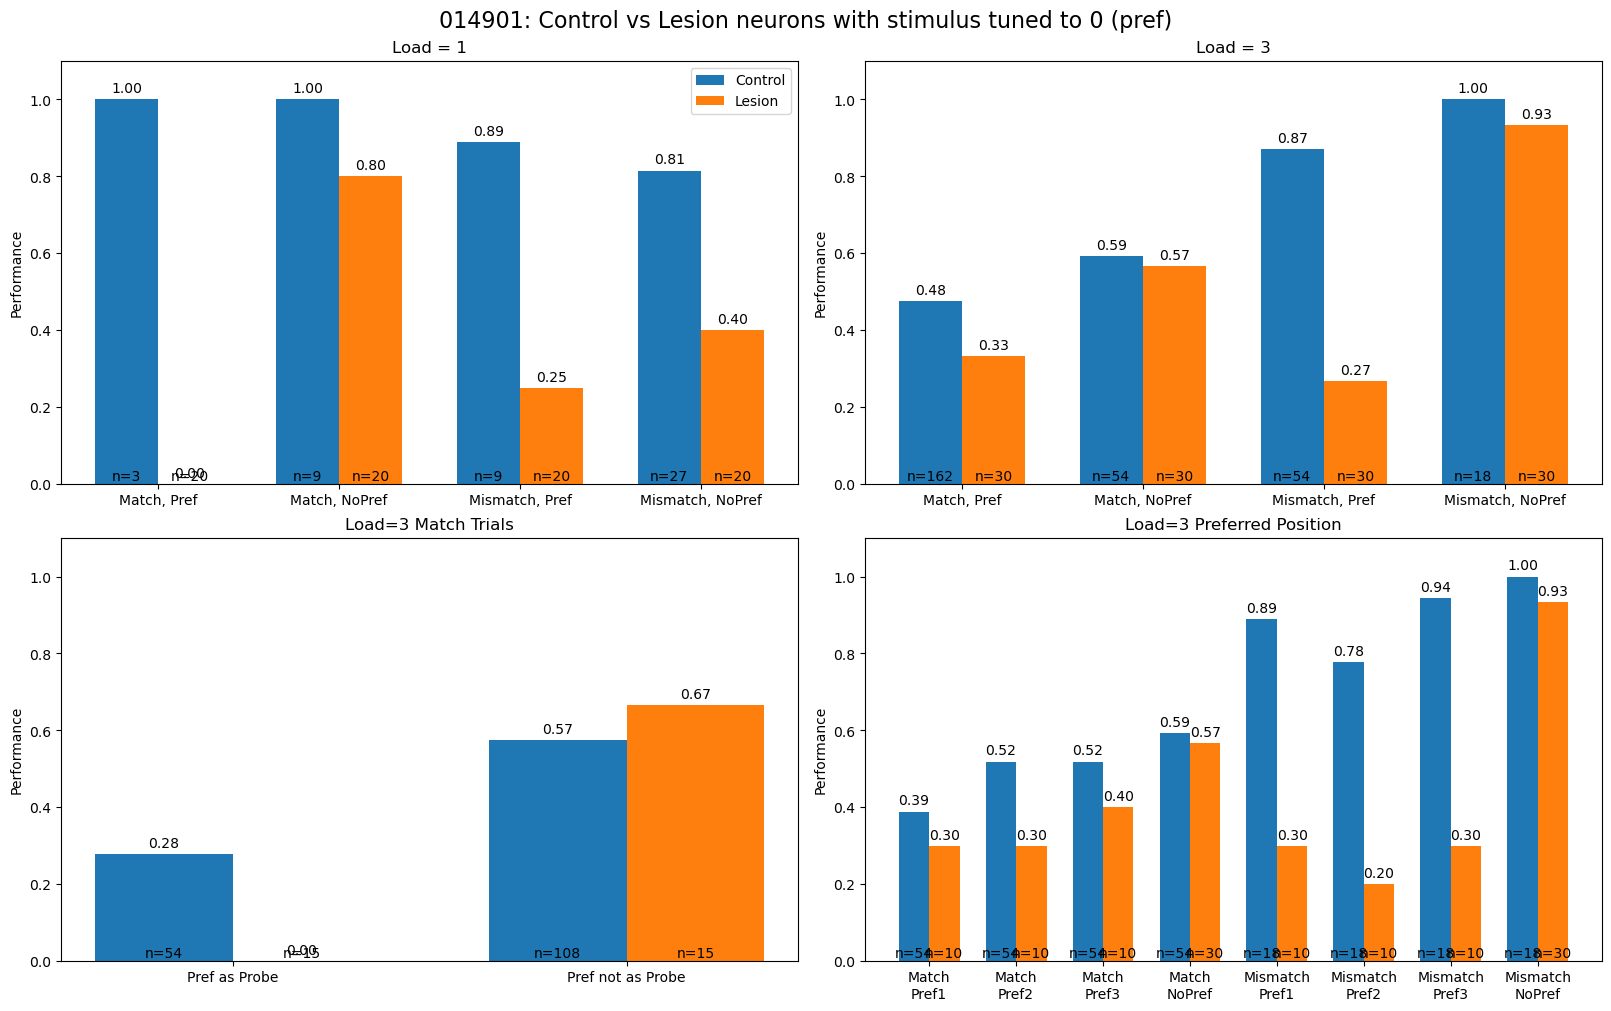

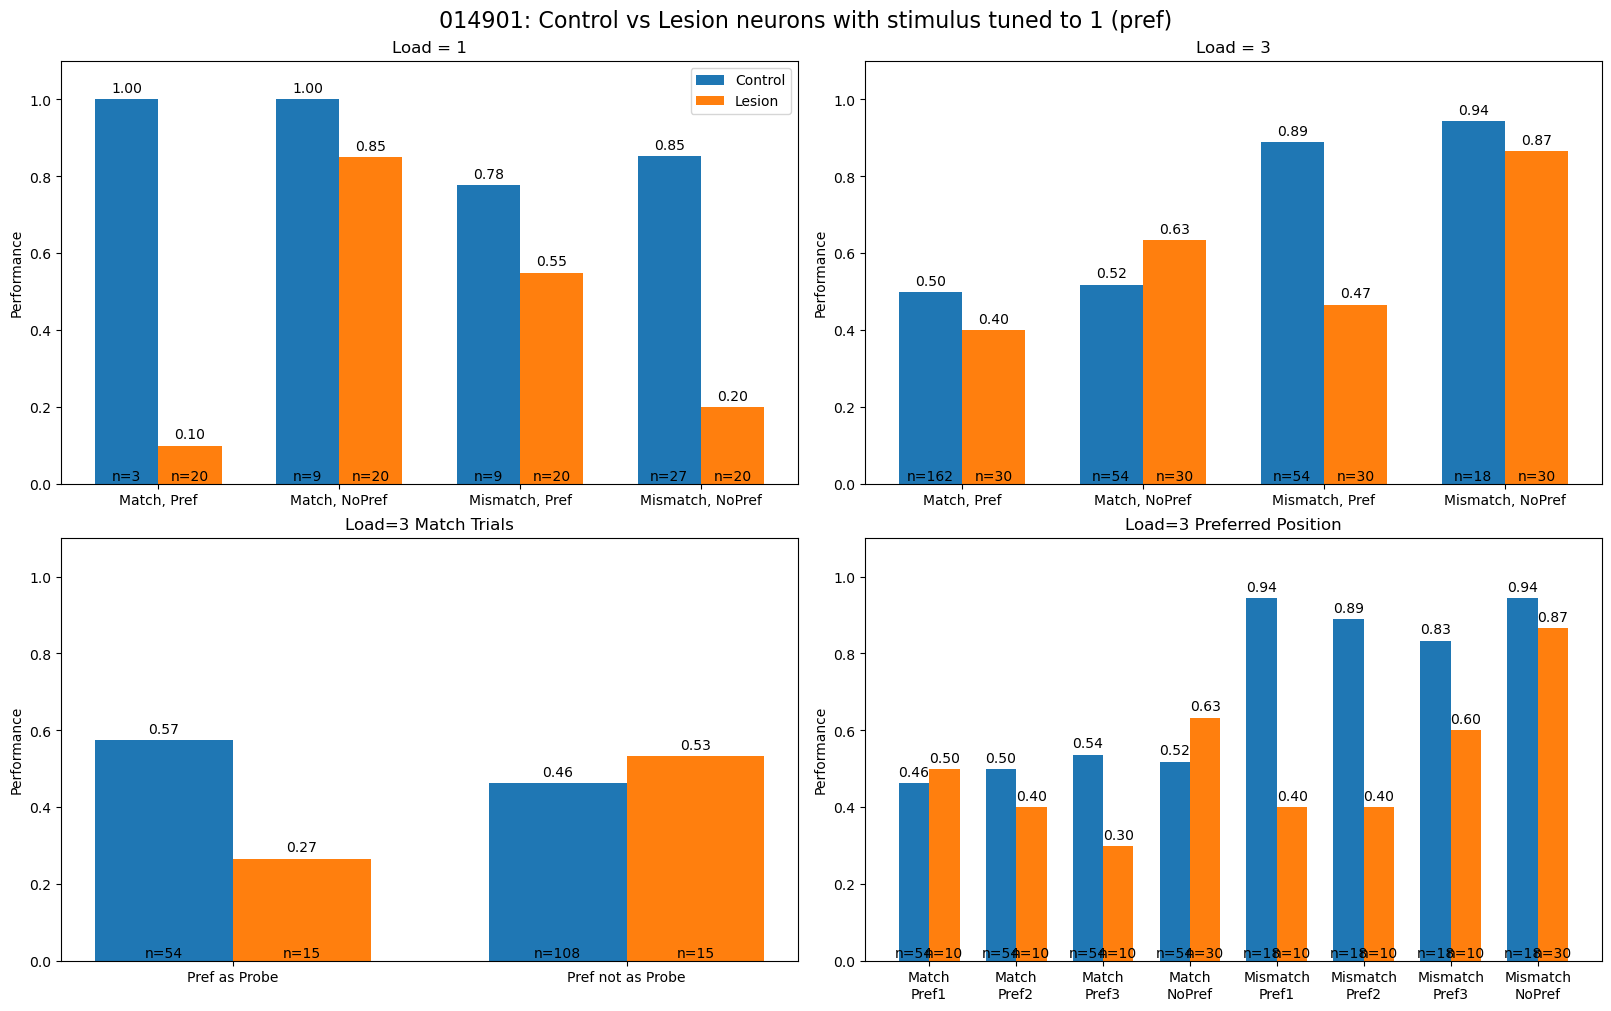

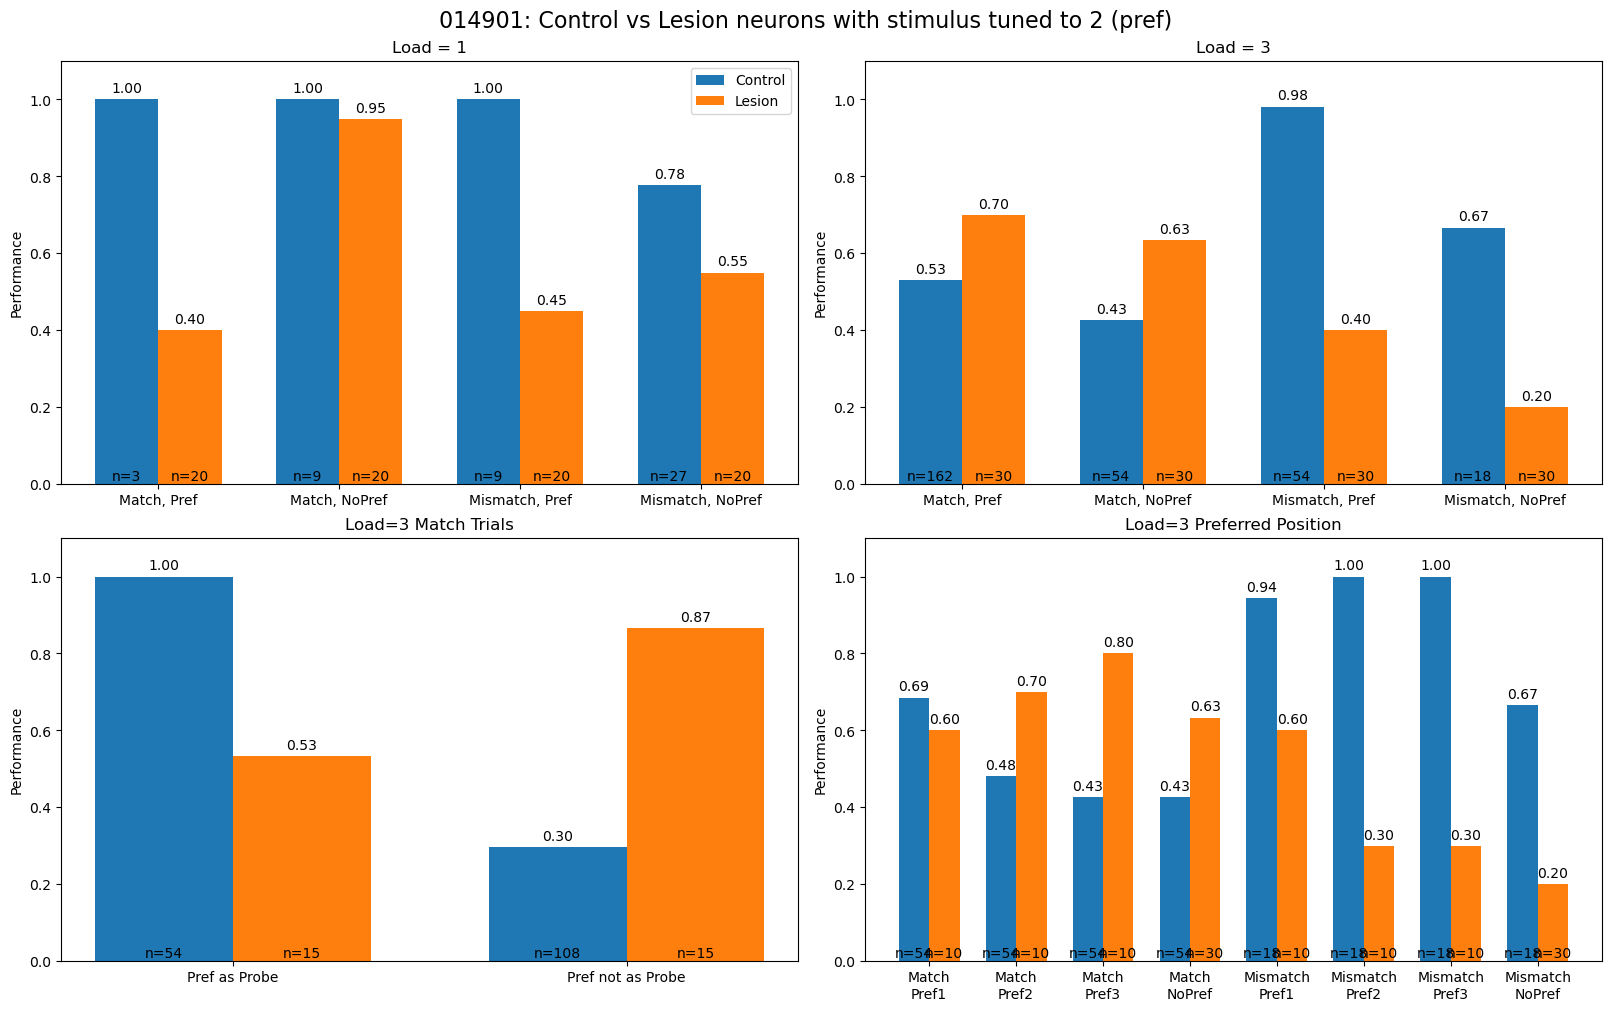

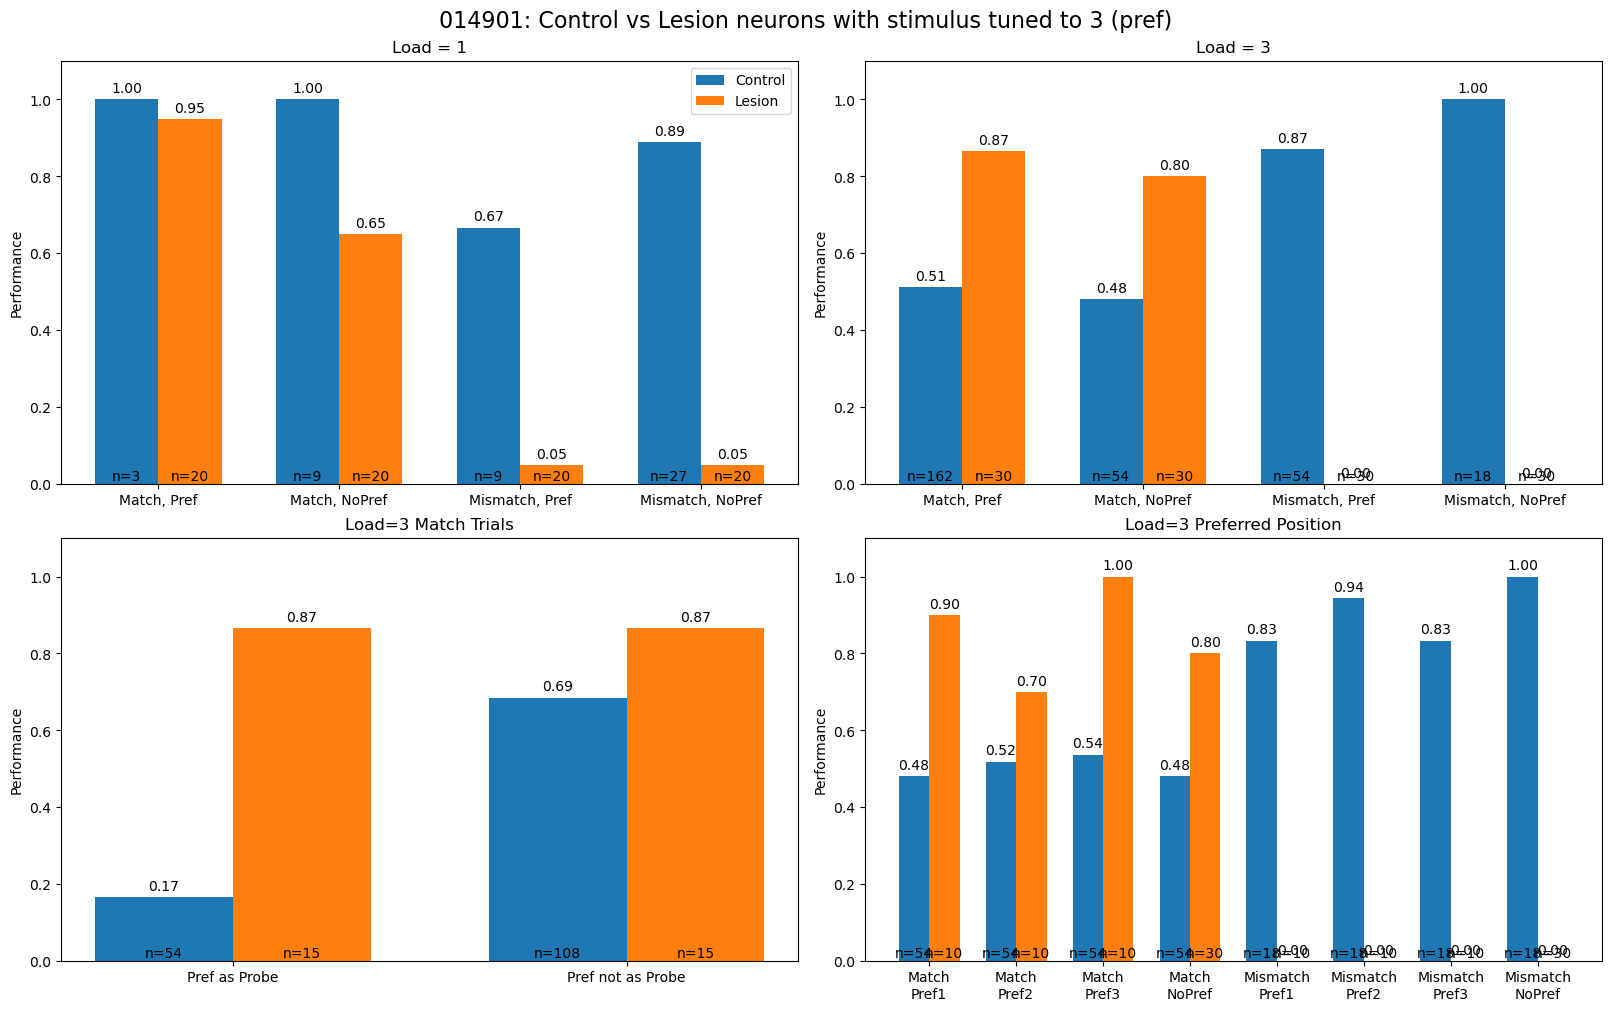

In [13]:
# load data and do some behavioral tests!
condn_phrase='delay'
condn_num=150

# load non-lesioned data
trial_labels_ctrl, trial_perfs_ctrl, _ = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num, other_labels='balance_stim', 
                                                            all_models_dir=all_models_dir)

unique_stims = np.unique(stim_tuning)
for stim_tuning in [0, 1, 2, 3]: # 0, 1, 2, 3

    other_labels=f'precomputed_lesion_stim_lesion0_stimpref_{stim_tuning}'

    trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels=other_labels,
                                                        all_models_dir=all_models_dir)
    
    
    fig, axs = plt.subplots(
        2, 2,
        figsize=(16, 10),
        constrained_layout=True
    )

    # panel 1: load=1
    ctrl_vals, ctrl_ns = get_stats(
        trial_labels_ctrl, trial_perfs_ctrl,
        stim_tuning, load=1
    )

    lesion_vals, lesion_ns = get_stats(
        trial_labels, trial_perfs,
        stim_tuning, load=1
    )

    plot_grouped_bars(
        axs[0,0],
        ctrl_vals, lesion_vals,
        ctrl_ns, lesion_ns,
        ['Match, Pref',
        'Match, NoPref',
        'Mismatch, Pref',
        'Mismatch, NoPref'],
        'Load = 1',
        show_legend=True
    )

    # panel 2: load=3
    ctrl_vals, ctrl_ns = get_stats(
        trial_labels_ctrl, trial_perfs_ctrl,
        stim_tuning, load=3
    )

    lesion_vals, lesion_ns = get_stats(
        trial_labels, trial_perfs,
        stim_tuning, load=3
    )

    plot_grouped_bars(
        axs[0,1],
        ctrl_vals, lesion_vals,
        ctrl_ns, lesion_ns,
        ['Match, Pref',
        'Match, NoPref',
        'Mismatch, Pref',
        'Mismatch, NoPref'],
        'Load = 3'
    )

    # panel 3: load=3, for match probe in, is pref the probe
    ctrl_vals, ctrl_ns = get_pref_probe_stats(
        trial_labels_ctrl,
        trial_perfs_ctrl,
        stim_tuning
    )

    lesion_vals, lesion_ns = get_pref_probe_stats(
        trial_labels,
        trial_perfs,
        stim_tuning
    )

    plot_grouped_bars(
        axs[1,0],
        ctrl_vals, lesion_vals,
        ctrl_ns, lesion_ns,
        ['Pref as Probe',
        'Pref not as Probe'],
        'Load=3 Match Trials'
    )

    # panel 4: load=3, preferred in specific position
    labels, ctrl_vals, ctrl_ns = get_means_ns(
        trial_labels_ctrl,
        trial_perfs_ctrl,
        stim_tuning
    )

    _, lesion_vals, lesion_ns = get_means_ns(
        trial_labels,
        trial_perfs,
        stim_tuning
    )

    plot_grouped_bars(
        axs[1,1],
        ctrl_vals, lesion_vals,
        ctrl_ns, lesion_ns,
        labels,
        'Load=3 Preferred Position'
    )

    # add a title to the figure
    fig.suptitle(
        f'{model_name[-6:]}: Control vs Lesion neurons with stimulus tuned to {stim_tuning} (pref)',
        fontsize=16
    )

    plt.show()

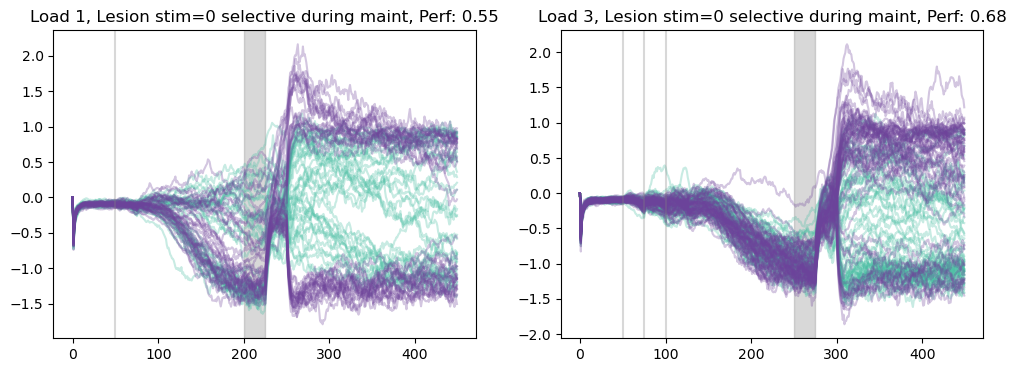

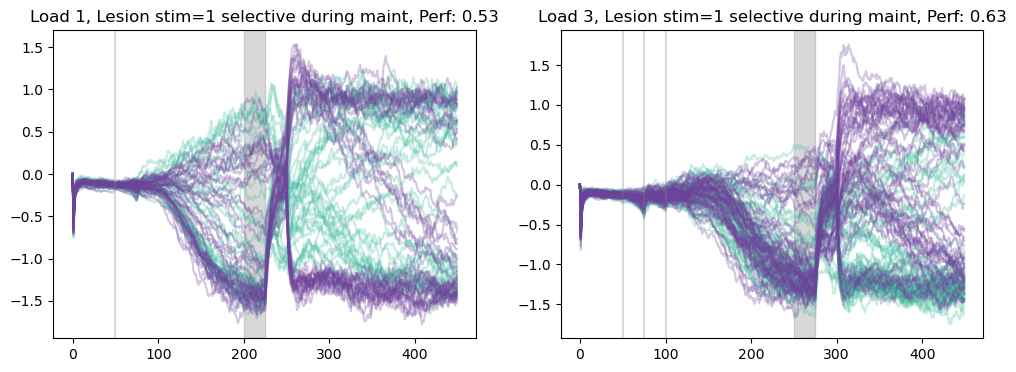

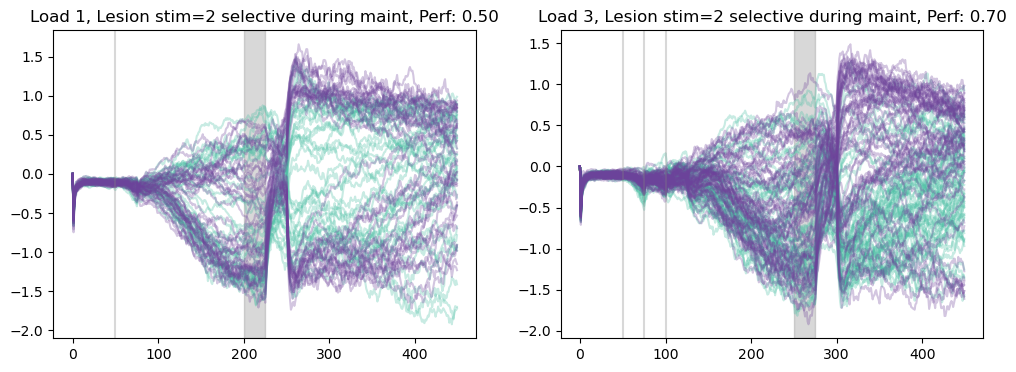

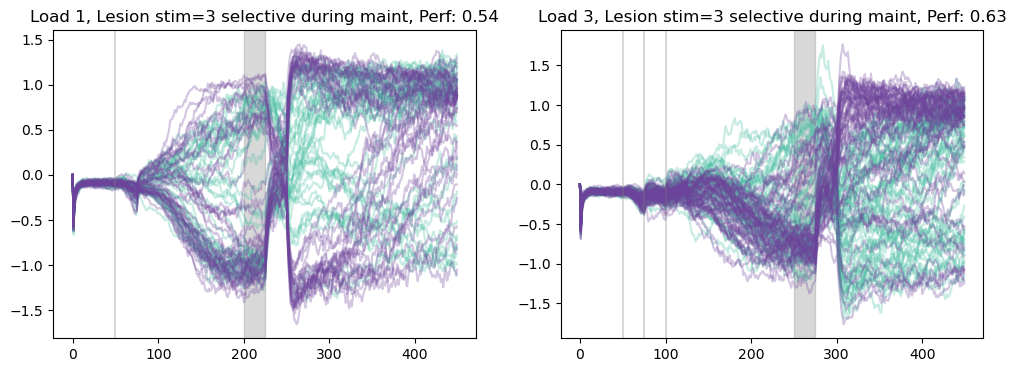

In [ ]:
# check out the outputs to make sure it's ok
condn_phrase='delay'
condn_num=150

# load non-lesioned data
trial_labels_ctrl, trial_perfs_ctrl, _ = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num, other_labels='balance_stim', 
                                                            all_models_dir=all_models_dir)

unique_stims = np.unique(stim_tuning)
for stim_tuning in [0, 1, 2, 3]: # 0, 1, 2, 3

    other_labels=f'precomputed_lesion_stim_stimpref_{stim_tuning}'

    trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels=other_labels,
                                                        all_models_dir=all_models_dir)
    
    # plot outputs
    colors = ["#49BEA3", "#6E439A"]
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    for i, load in enumerate([1, 3]):
        this_load_idx = np.where(trial_labels[:, 0] == load)[0]
        for n in this_load_idx:
            axs[i].plot(
                trial_outputs[n],
                color=colors[int(trial_labels[n,1] == 1)],
                alpha=0.3,
            )

        perf = np.mean(np.array(trial_perfs)[this_load_idx])
        axs[i].set_title(f"Load {load}, Lesion stim={stim_tuning} selective during maint, Perf: {perf:.2f}")
        for n in range(load):
            stim_on = settings["stim_on"] + n * settings["stim_dur"]
            axs[i].axvline(stim_on, color="gray", alpha=0.3)
        axs[i].axvspan(
            stim_on + settings["delay"],
            stim_on + settings["delay"] + settings["stim_dur"],
            color="gray",
            alpha=0.3,
        )
    plt.show()